# Generate samples

In [11]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import BurstPrismaDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False
eid = "E118"
fold = 0
# remove_marks = "H3K36me3"
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['marks_nums'] - len(config["remove_marks"])


d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]

regulation_kws = config["regulation"]


d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

if remove_marks:
    checkpoints = f"checkpoints/{eid}.remove_{remove_marks}.{fold}.model.pt"
elif not add_feature_bin:
    checkpoints = f"checkpoints/{eid}.{fold}.model.pt"
else:
    checkpoints = f"checkpoints/{eid}.{fold}.model.pt"
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"


binsizes = [500]


#
# Setup end.
#

seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

# Split genes into two sets (train/val).
genes = set(meta.gene_id.unique())
n_genes = len(genes)
print("Target genes:", len(genes))
print(f"n_feats_p:{n_feats_p}")

splits = {
    1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
    2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
    3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
    4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
}

chromosome_splits = {}
for key, chroms in splits.items():
    for chrom in chroms:
        chromosome_splits[chrom] = key

qs = [
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
]

train_genes = (
    qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
)
val_genes = qs[(fold + 3) % 4]



print(len(train_genes), len(val_genes))

val_dataset = BurstPrismaDataset(
    meta_path,
    npy_dir,
    val_genes,
    i_max,
    binsizes,
    w_prom,
    w_max,
    config = config,
    with_gene_id=True
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

model = BurstPrisma(
    n_feats_p,
    d_emb,
    d_head,
    embed_kws=embed_kws,
    binsizes=binsizes,
    seed=42,
    targets=targets,
).to(DEVICE)
    n_feats_p,
    n_feats_pcres,
    d_emb,
    d_head,
    feature_bin_kws=feature_bin_kws,
    embed_kws=embed_kws,
    binsizes=binsizes,
    seed=42,
    targets=targets,
    add_feature_bin = add_feature_bin,
).to(DEVICE)

ckpt = torch.load(checkpoints,map_location=DEVICE)
model.load_state_dict(ckpt["net"])


Target genes: 13900
n_feats_p:7
10545 3355


<All keys matched successfully>

In [12]:
def evaluation(out:'torch.Tensor', label:torch.Tensor):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return label, pred, acc, auc, ap

In [13]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Generate samples with the scores

In [14]:
with open('extra/datasets/results/indicators.csv','w') as w:
    line = ['eid','target','indicator','value','fold']
    w.write(','.join(line) + '\n')
    for _eid in ["E003","E118","E116"]:
        data = pd.read_csv(f'extra/datasets/results/{_eid}_No_feature_bin_predictions.csv')

        for _fold in [0,1,2,3]:
            _data = data[data['fold']==_fold]
            for target in targets:
                label = _data[f'{target}_label']
                pred = _data[f'{target}_pred']
                score = _data[f'{target}_score']
                acc = metrics.accuracy_score(label, pred) * 100
                auc = metrics.roc_auc_score(label, score) * 100
                ap = metrics.average_precision_score(label, score) * 100
                line = [_eid,target,'AUC',str(auc),str(fold)]          
                w.write(','.join(line) + '\n')
                line = [_eid,target,'ACC',str(acc),str(fold)]          
                w.write(','.join(line) + '\n')
                line = [_eid,target,'AP',str(ap),str(fold)]          
                w.write(','.join(line) + '\n')




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


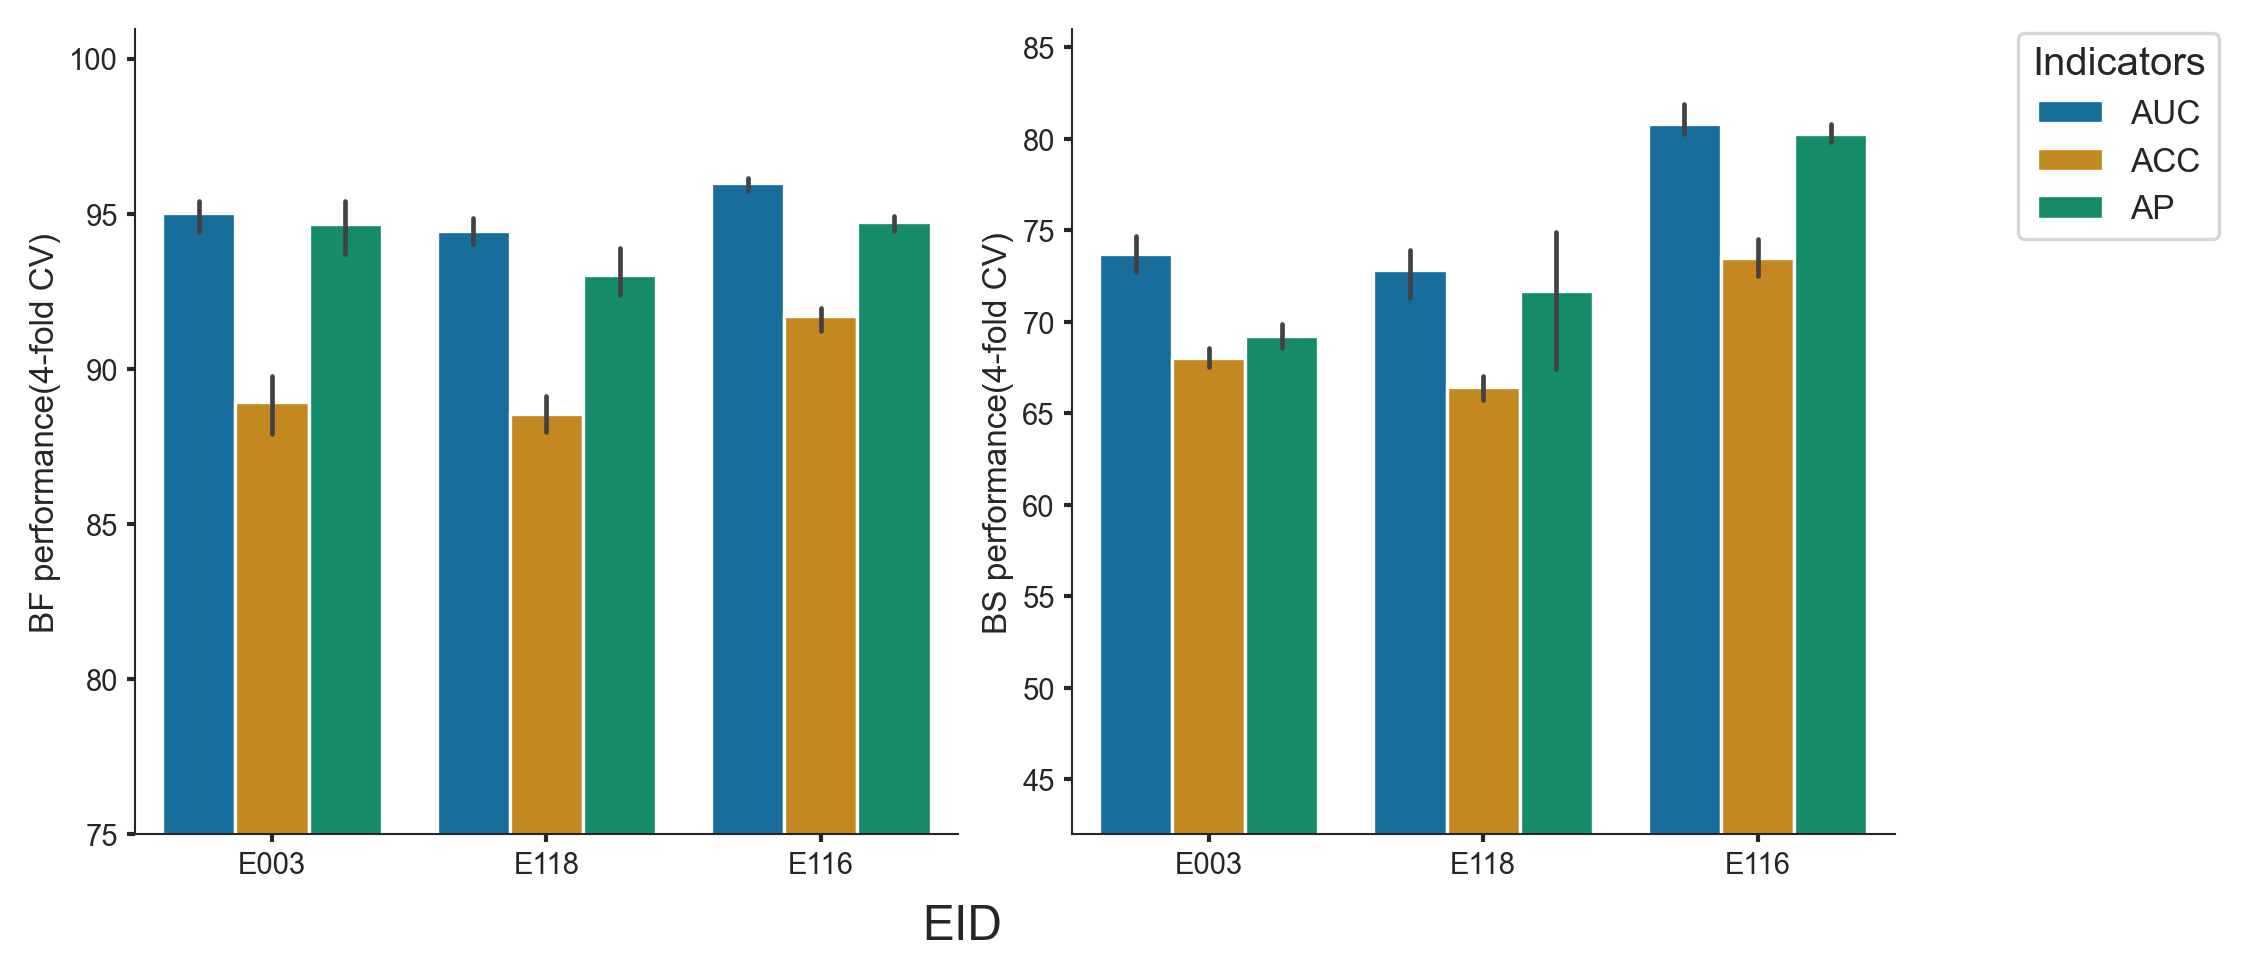

In [15]:
indicators = pd.read_csv('extra/datasets/results/indicators.csv')

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(16/2.54, 8/2.54))

sns.barplot(data=indicators[indicators['target']=='bf_label'],x='eid',y='value',hue='indicator',ax=ax[0])
sns.barplot(data=indicators[indicators['target']=='bs_label'],x='eid',y='value',hue='indicator',ax=ax[1])

# plt.legend(loc='upper left', bbox_to_anchor=(1, 1),title='Indicators',fontsize=8)  # Moves the legend outside the 
# plt.legend().remove()
# Show the plot
ax[0].set_ylabel("BF performance(4-fold CV)")
ax[1].set_ylabel("BS performance(4-fold CV)")
fig.supxlabel('EID')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xlabel('')

ax[0].set_ylim(ymin=75)
ax[1].set_ylim(ymin=42)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), title='Indicators', fontsize=8)
plt.savefig('extra/datasets/figures/Figure2.c.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

In [16]:
data = pd.read_csv(f'extra/datasets/results/{eid}_No_feature_bin_predictions.csv')
data

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold
0,ENSG00000176024,0,0.406165,0,1,0.653990,1,0
1,ENSG00000136848,0,0.261755,0,1,0.008434,0,0
2,ENSG00000139832,0,0.815321,1,1,0.933674,1,0
3,ENSG00000100055,0,0.263797,0,0,0.010802,0,0
4,ENSG00000235034,1,0.282971,0,0,0.013444,0,0
...,...,...,...,...,...,...,...,...
13895,ENSG00000101557,1,0.584293,1,1,0.953765,1,3
13896,ENSG00000242366,1,0.182573,0,0,0.016641,0,3
13897,ENSG00000144867,1,0.632004,1,1,0.938501,1,3
13898,ENSG00000065413,1,0.458809,0,0,0.029908,0,3


## Burst Frequency Test Data AURoc

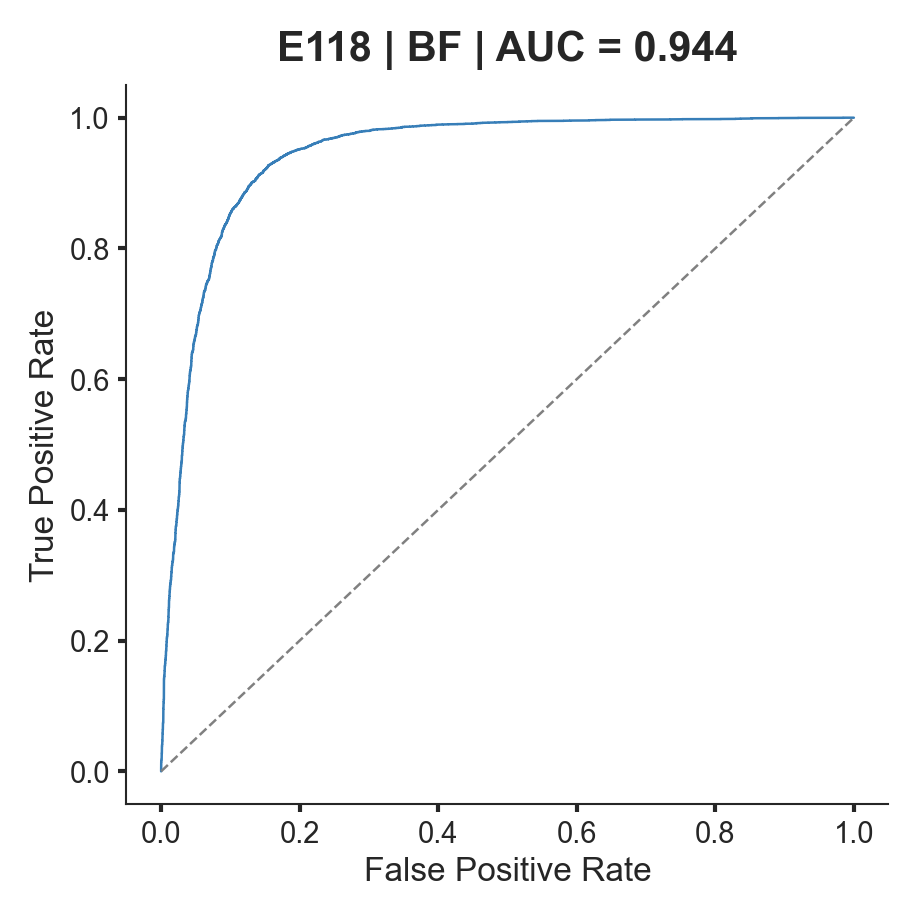

In [17]:
# 

fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BF | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()


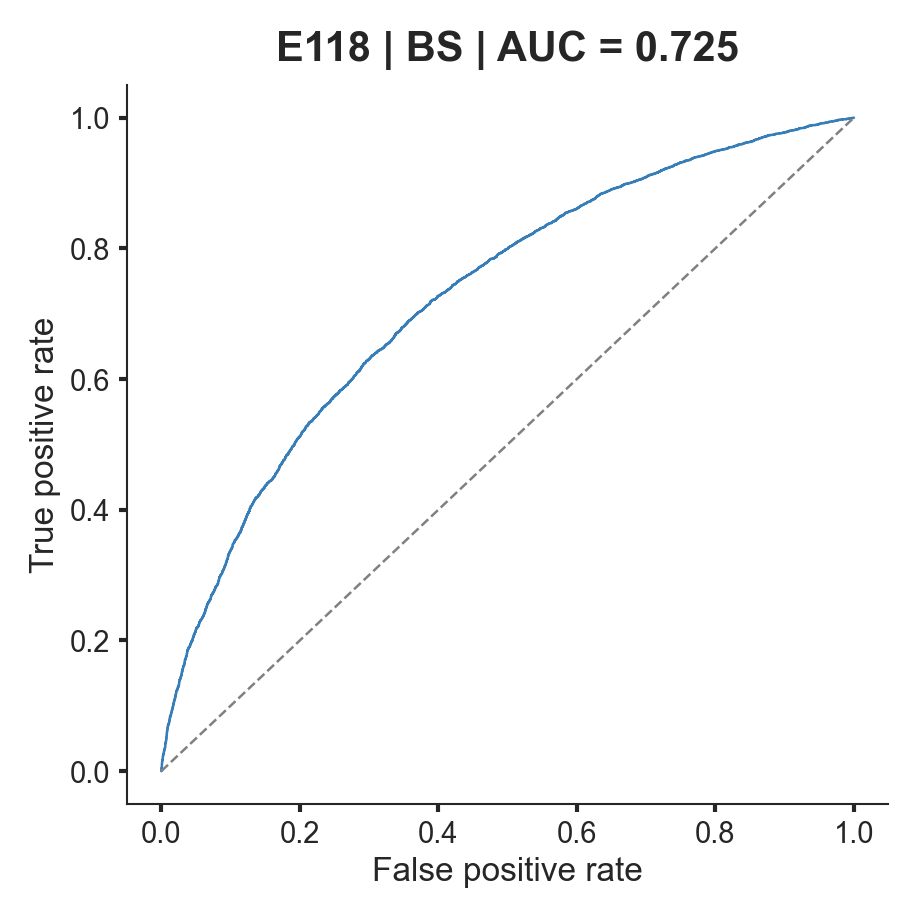

In [18]:
fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bs_label_label'],data['bs_label_pred'])

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BS | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()

## Expression vs burst size / frequency 

In [19]:
data = pd.read_csv(f'extra/datasets/results/{eid}_No_feature_bin_predictions.csv')
    
data = pd.merge(data,meta[['gene_id','mean','mean_label']], how='inner',on='gene_id')

data['mean'] = np.log1p(data['mean'])

LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
def mark_label(x,y):
    if x == 0 and y==0:
        return  LABEL_BIN_MAP["Low bs and low bf"]
    if x == 1 and y ==0:
        return LABEL_BIN_MAP["High bs and low bf"]
    if x == 0 and y==1:
        return LABEL_BIN_MAP["Low bs and high bf"]
    if x == 1 and y == 1:
        return LABEL_BIN_MAP["High bs and high bf"]
data['pred_marks'] = data.apply(lambda row:mark_label(row['bs_label_pred'],row['bf_label_pred']), axis=1)
data['labels_marks'] = data.apply(lambda row:mark_label(row['bs_label_label'],row['bf_label_label']), axis=1)
data 

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,mean,mean_label,pred_marks,labels_marks
0,ENSG00000176024,0,0.406165,0,1,0.653990,1,0,0.139655,0,C3,C3
1,ENSG00000136848,0,0.261755,0,1,0.008434,0,0,0.832268,1,C1,C3
2,ENSG00000139832,0,0.815321,1,1,0.933674,1,0,0.767124,1,C4,C3
3,ENSG00000100055,0,0.263797,0,0,0.010802,0,0,0.000614,0,C1,C1
4,ENSG00000235034,1,0.282971,0,0,0.013444,0,0,0.100434,0,C1,C2
...,...,...,...,...,...,...,...,...,...,...,...,...
13895,ENSG00000101557,1,0.584293,1,1,0.953765,1,3,1.630348,1,C4,C4
13896,ENSG00000242366,1,0.182573,0,0,0.016641,0,3,0.150282,0,C1,C2
13897,ENSG00000144867,1,0.632004,1,1,0.938501,1,3,1.625040,1,C4,C4
13898,ENSG00000065413,1,0.458809,0,0,0.029908,0,3,0.045039,0,C1,C2


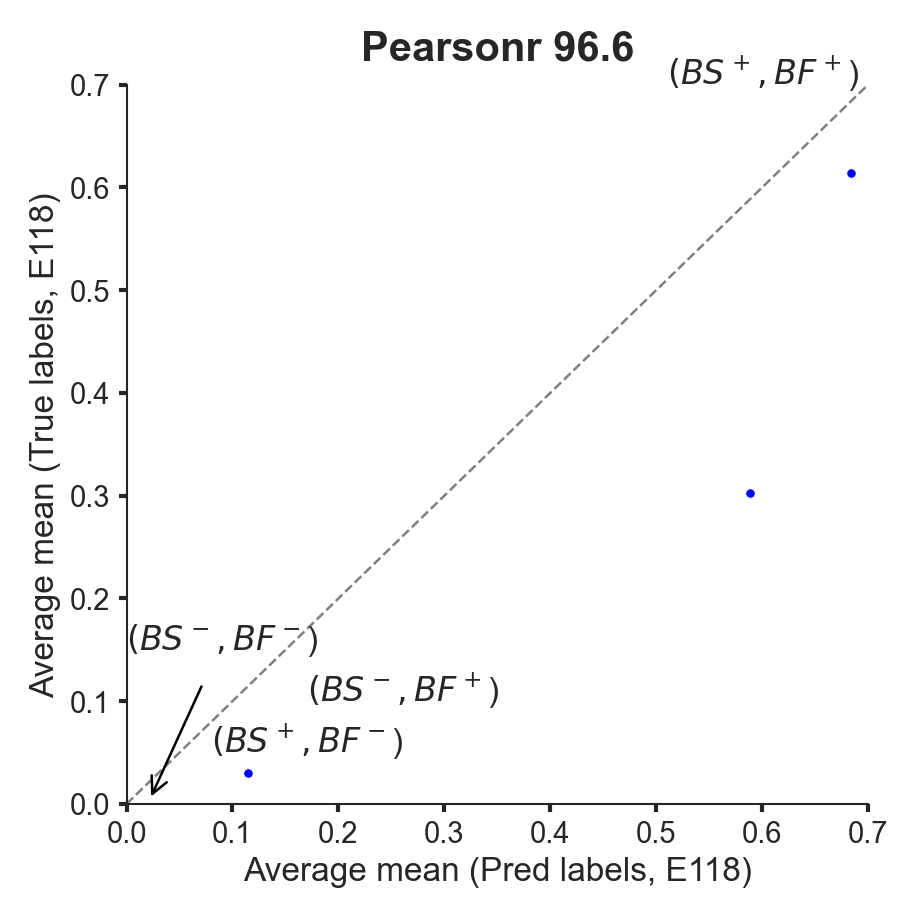

In [20]:
pred_marks = data[['pred_marks','mean']].groupby(by='pred_marks',as_index=False).mean()
pred_marks.columns = ['bins','mean']
labels_marks = data[['labels_marks','mean']].groupby(by='labels_marks',as_index=False).mean()
labels_marks.columns = ['bins','mean']

df_marks = pd.merge(pred_marks,labels_marks,on='bins')
r = stats.pearsonr(df_marks['mean_x'], df_marks['mean_y'])[0] * 100


ax = sns.scatterplot(data=df_marks,x='mean_x',y='mean_y',s=5,color='blue')

ax.set_xlim(xmin=0,xmax=0.7)
ax.set_ylim(ymin=0,ymax=0.7)
ax.set_xlabel(f"Average mean (Pred labels, {eid})")
ax.set_ylabel(f"Average mean (True labels, {eid})")

plt.plot([0, 0.7], [0, 0.7], lw=0.6, color='gray', linestyle='--')

ax.annotate("$(BS^-,BF^-$)", xy=(0.02, 0), xytext=(0,0.15), 
            arrowprops=dict(facecolor='black', edgecolor='black', 
                            linewidth=0.6, arrowstyle='->', 
                            shrinkA=5, lw=0.6, mutation_scale=10),fontsize=8)
# plt.text(0,0.2,"$(BS^-,BF^-$)",fontdict={"size":4})
plt.text(0.08,0.05,"$(BS^+,BF^-$)",fontdict={"size":8})
plt.text(0.17,0.1,"$(BS^-,BF^+$)",fontdict={"size":8})
plt.text(0.51,0.7,"$(BS^+,BF^+$)",fontdict={"size":8})
plt.title(f"Pearsonr {round(r,2)}")
plt.savefig('extra/datasets/figures/Figure2.e_2.eps', format='eps', bbox_inches='tight')

plt.show()




/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/3907245638.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['type'] = 'Pred labels'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/3907245638.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['type'] = 'True labels'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/3907245638.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

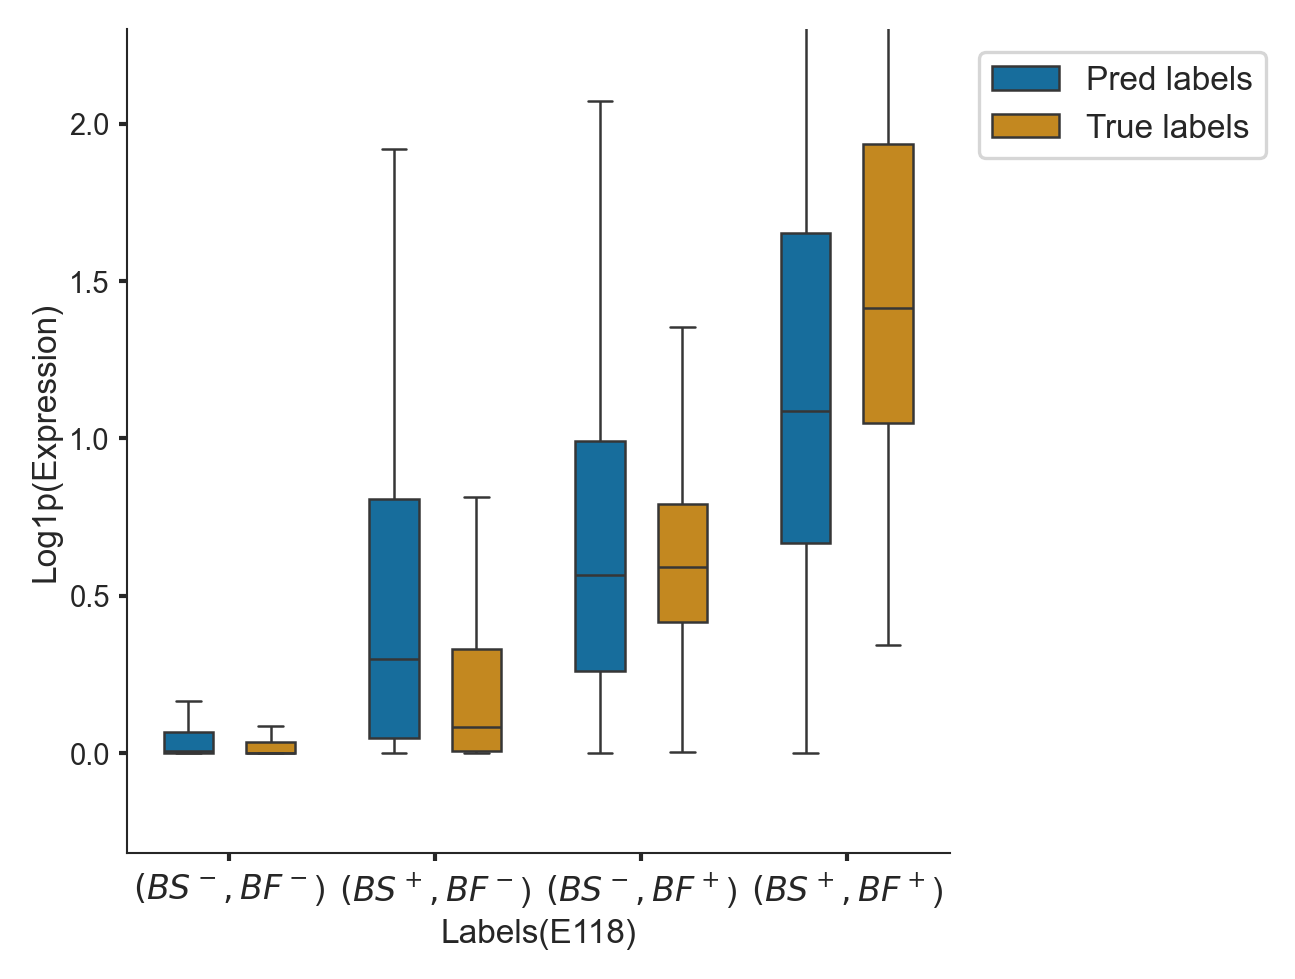

In [21]:
# 设置为 colorblind 调色板
sns.set_palette("colorblind")
# sns.set_context("paper") 
order = pd.Index(["C1","C2","C3","C4"],name='marks')

df1 = data[['mean','pred_marks']]
df1.columns = ['mean','mark']
df1['type'] = 'Pred labels'

df2 = data[['mean','labels_marks']]
df2.columns = ['mean','mark']
df2['type'] = 'True labels'
fig, ax = plt.subplots(1, 1, constrained_layout=True)

df = pd.concat([df1,df2],axis=0)

ax = sns.boxplot(data=df,y='mean',x='mark',hue='type',gap=0.4,width=0.8,fliersize=0,order=order,linewidth=0.6)
ax.set_ylabel(f'Log1p(Expression)')
ax.set_xlabel(f'Labels({eid})')
ax.set_ylim(top=2.3)
ax.set_xticklabels(["$(BS^-,BF^-$)","$(BS^+,BF^-$)","$(BS^-,BF^+$)","$(BS^+,BF^+$)"],fontdict = {"size":8})  # ha参数用于设置水平对齐方式
ax.legend().remove()
fig.legend(loc='upper left', bbox_to_anchor=(1, 0.98))  # Moves the legend outside the 
# plt.legend().remove()
# Show the plot
plt.savefig('extra/datasets/figures/Figure2.e_1.eps', format='eps', bbox_inches='tight')

plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/716744421.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['type'] = 'Pred label'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/716744421.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['type'] = 'True label'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/716744421.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLo

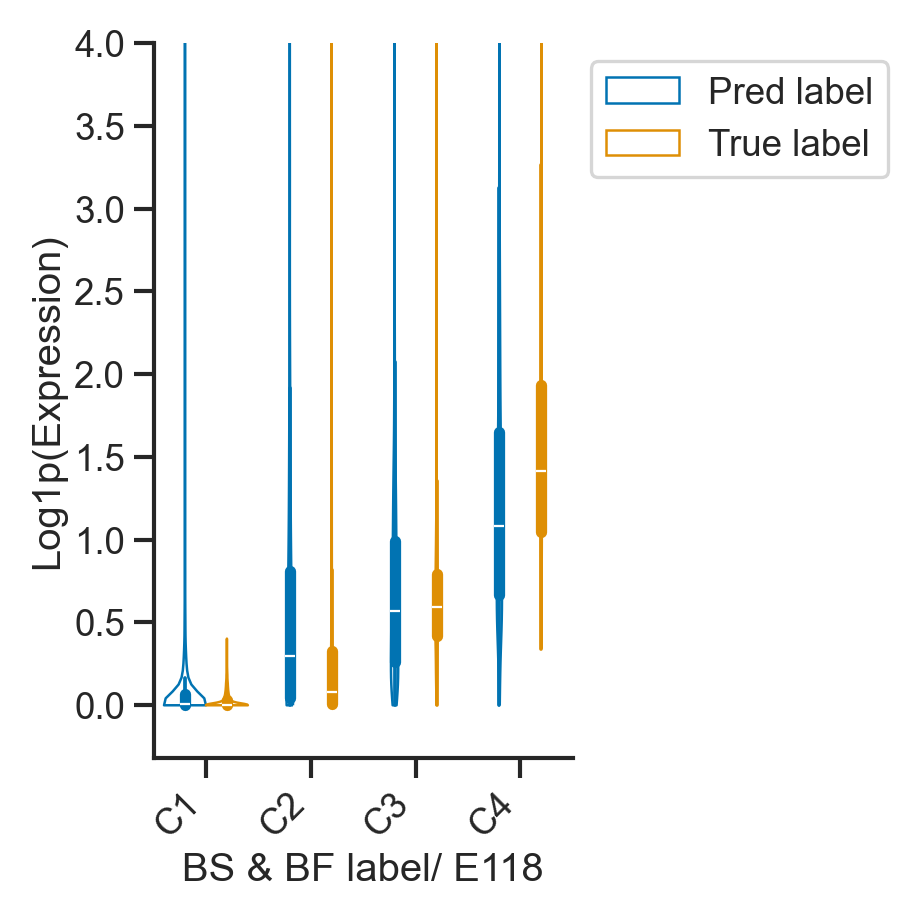

In [22]:
# 设置为 colorblind 调色板
sns.set_palette("colorblind")
sns.set_context("paper") 
df1 = data[['mean','pred_marks']]
df1.columns = ['mean','mark']
df1['type'] = 'Pred label'

df2 = data[['mean','labels_marks']]
df2.columns = ['mean','mark']
df2['type'] = 'True label'

df = pd.concat([df1,df2],axis=0)

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

ax = sns.violinplot(data=df,x='mark',y='mean',hue='type',order=order,cut=0,fill=False,linewidth=0.6)
plt.ylabel(f'Log1p(Expression)')
plt.xlabel(f'BS & BF label/ {eid}')
ax.set_ylim(top=4)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # ha参数用于设置水平对齐方式
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the 
# plt.legend().remove()
# Show the plot
plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

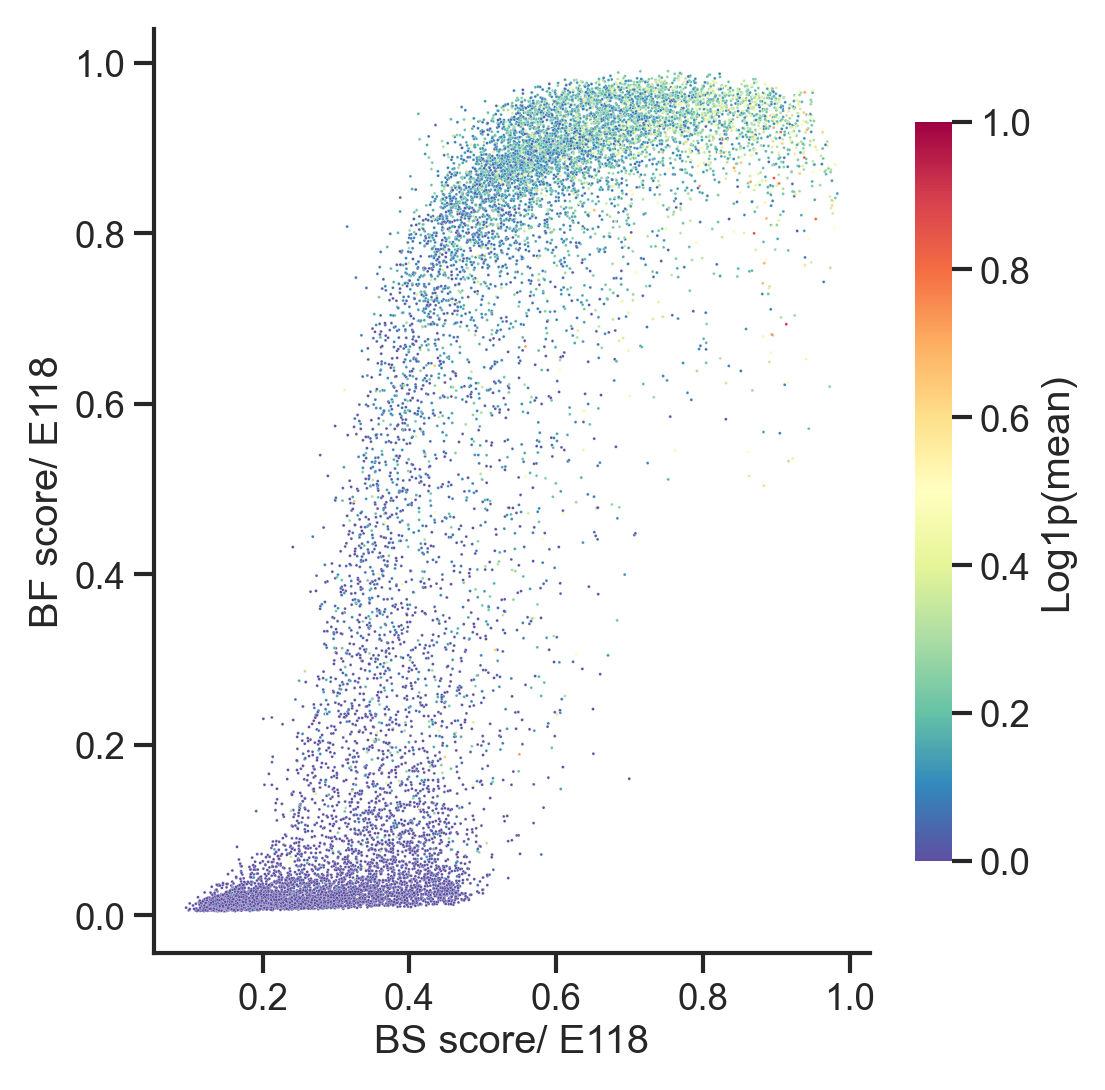

In [23]:


# Create the figure and axes
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300, facecolor='w', edgecolor='k')
fig.tight_layout(pad=1)

# Create the scatter plot
scatter = sns.scatterplot(
    x=data['bs_label_score'],
    y=data['bf_label_score'],
    hue=data['mean'],  # Use 'hue' to map colors
    palette='Spectral_r',  # Specify the colormap
    s=0.5,  # Set marker size to 0.1
    legend=False,  # Disable the legend
    ax=ax  # Specify the axes to plot on
)

# Add a colorbar
norm = plt.Normalize(data['mean'].min(), data['mean_label'].max())
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Log1p(mean)',shrink=0.8,location='right')  # Associate colorbar with the axes
cbar.outline.set_visible(False)
plt.ylabel(f"BF score/ {eid}")
plt.xlabel(f"BS score/ {eid}")

# Show the plot
plt.show()

/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


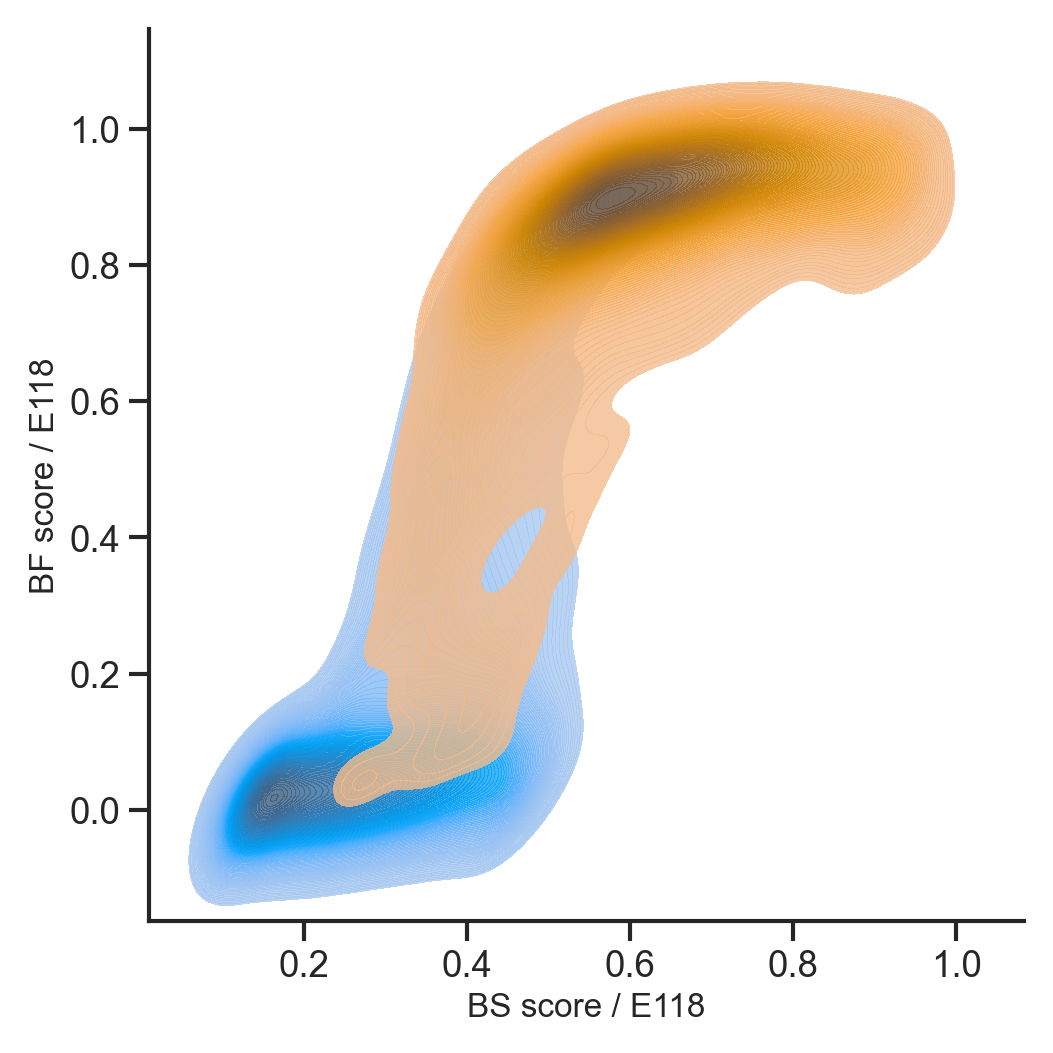

In [24]:

# Optimize imports
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure and axes
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300, facecolor='w', edgecolor='k')
fig.tight_layout(pad=1)


# Extract data for high and low expression
high_expr = data[data['mean_label'] == 1]
low_expr = data[data['mean_label'] == 0]
# Plot density for "High expression" (red)
sns.kdeplot(
    data=data,
    x='bs_label_score',
    y='bf_label_score',
    levels=100,
    hue='mean_label',
    fill=True,
    cmap="Reds",
    alpha=0.8,
    ax=ax  # Explicitly pass the axis
)

# Add legend
plt.legend(loc="upper right",  bbox_to_anchor=(1, 1)).remove()

# Label axes
plt.ylabel(f"BF score / {eid}", fontsize=8)
plt.xlabel(f"BS score / {eid}", fontsize=8)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [25]:
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}
# superenhencer = pd.read_csv(f'extra/datasets/diHMM/{EIDS_TO_CELLTYPES[eid]}/superenhancer.txt', sep='\t', names=['chrom','start','end','domain_level','strand','gene_id'])
# superenhencer['active'] = 1
# h3k27me3 = pd.read_csv(f'extra/datasets/diHMM/{EIDS_TO_CELLTYPES[eid]}/H3K27me3_silenced.txt', sep='\t', names=['chrom','start','end','domain_level','strand','gene_id'])
# h3k27me3['h3k27me3'] = 1

# h3k36me3 = pd.read_csv(f'extra/datasets/diHMM/{EIDS_TO_CELLTYPES[eid]}/H3K36me3_silenced.txt', sep='\t', names=['chrom','start','end','domain_level','strand','gene_id'])
# h3k36me3['h3k36me3'] = 1

# data = pd.merge(data,superenhencer[['gene_id','active']].drop_duplicates(), how='left', on='gene_id')
# data = pd.merge(data,h3k27me3[['gene_id','h3k27me3']].drop_duplicates(), how='left', on='gene_id')
# data = pd.merge(data,h3k36me3[['gene_id','h3k36me3']].drop_duplicates(), how='left', on='gene_id')
# data = data.fillna(0)
# data.to_csv(f'extra/datasets/results/{eid}_results.csv',index=False)
data


,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,mean,mean_label,pred_marks,labels_marks
0,ENSG00000176024,0,0.406165,0,1,0.653990,1,0,0.139655,0,C3,C3
1,ENSG00000136848,0,0.261755,0,1,0.008434,0,0,0.832268,1,C1,C3
2,ENSG00000139832,0,0.815321,1,1,0.933674,1,0,0.767124,1,C4,C3
3,ENSG00000100055,0,0.263797,0,0,0.010802,0,0,0.000614,0,C1,C1
4,ENSG00000235034,1,0.282971,0,0,0.013444,0,0,0.100434,0,C1,C2
...,...,...,...,...,...,...,...,...,...,...,...,...
13895,ENSG00000101557,1,0.584293,1,1,0.953765,1,3,1.630348,1,C4,C4
13896,ENSG00000242366,1,0.182573,0,0,0.016641,0,3,0.150282,0,C1,C2
13897,ENSG00000144867,1,0.632004,1,1,0.938501,1,3,1.625040,1,C4,C4
13898,ENSG00000065413,1,0.458809,0,0,0.029908,0,3,0.045039,0,C1,C2


In [70]:
# h3k27me3 = data[data['h3k27me3']==1]
# superenhencer = data[data['active']==1]
# h3k36me3 =  data[data['h3k36me3']==1]
# h3k36me3


,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,mean,mean_label,pred_marks,labels_marks,active,h3k27me3,h3k36me3
0,ENSG00000054611,1,0.961865,1,1,0.980953,1,0,0.430006,1,C4,C4,1.0,1.0,1.0
2,ENSG00000184164,1,0.892111,1,1,0.967126,1,0,1.758548,1,C4,C4,0.0,0.0,1.0
4,ENSG00000102309,1,0.451373,0,1,0.872739,1,0,0.660797,1,C3,C4,0.0,0.0,1.0
6,ENSG00000100030,1,0.864212,1,1,0.976639,1,0,0.405925,1,C4,C4,1.0,1.0,1.0
7,ENSG00000136802,0,0.723731,1,1,0.968372,1,0,0.092074,1,C4,C3,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15633,ENSG00000109265,1,0.281950,0,0,0.059629,0,3,0.001035,0,C1,C2,0.0,1.0,1.0
15634,ENSG00000136699,1,0.695502,1,1,0.961138,1,3,0.222177,1,C4,C4,1.0,0.0,1.0
15635,ENSG00000156219,0,0.180331,0,0,0.010326,0,3,0.000690,0,C1,C1,0.0,1.0,1.0
15638,ENSG00000114857,1,0.856059,1,1,0.976155,1,3,0.677585,1,C4,C4,0.0,1.0,1.0


### Correlation between HMs

In [2]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=axis,vmin=vmin, vmax=vmax)
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        axis.set_xlabel(xlabel)
    
    if ylabel:
        axis.set_ylabel(ylabel)

    if xticklabels:
        axis.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels)

    g.set_title(title)


In [26]:
eid='E003'
from src.data.utils import bin_and_padding
# data = pd.read_csv(f'extra/datasets/results/{eid}_results.csv')

df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')
gene_ids = list(df[['gene_id','strand']].values)

marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in gene_ids])



/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


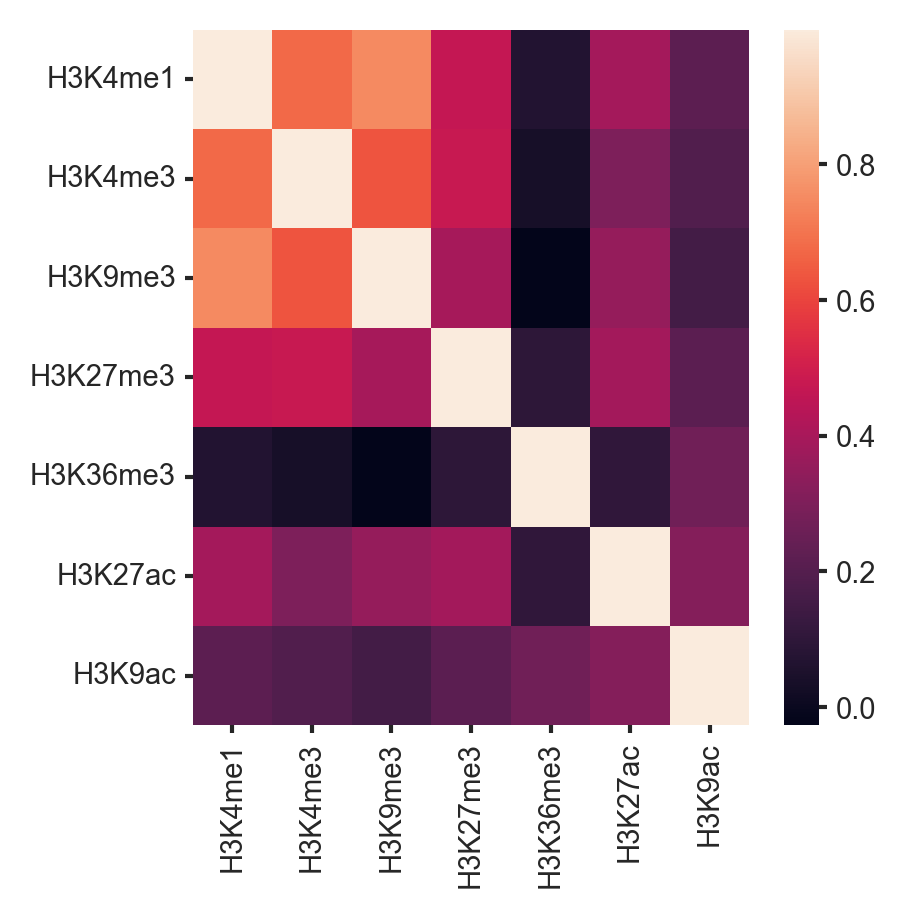

In [7]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
ticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in ticks]

correlation_matrices = [np.nan_to_num(np.corrcoef(mark[idxes])) for mark in marks]
correlation = np.mean(correlation_matrices,axis=0)

# correlation
np.savetxt(f"extra/datasets/results/{eid}_hm_correlation.csv", correlation, delimiter=",", fmt="%.3f") 
correlation = np.loadtxt(f'extra/datasets/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵

MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
ax = sns.heatmap(correlation)
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
plt.show()


### BS pred score marks strength

In [71]:
from src.data.utils import bin_and_padding
# data = pd.read_csv(f'extra/datasets/results/{eid}_results.csv')
data1 = data[data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and low bf']])]

df = pd.merge(data1,meta[['gene_id','strand']],how='inner',on='gene_id')
# high_gene_ids = list(df[['gene_id','strand']].values)[:100]
high_gene_ids = list(df[df['labels_marks']==LABEL_BIN_MAP['High bs and low bf']][['gene_id','strand']].values)

high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)

# low_gene_ids = list(df[['gene_id','strand']].values)[-100:]
low_gene_ids = list(df[df['labels_marks']==LABEL_BIN_MAP['Low bs and low bf']][['gene_id','strand']].values)
low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


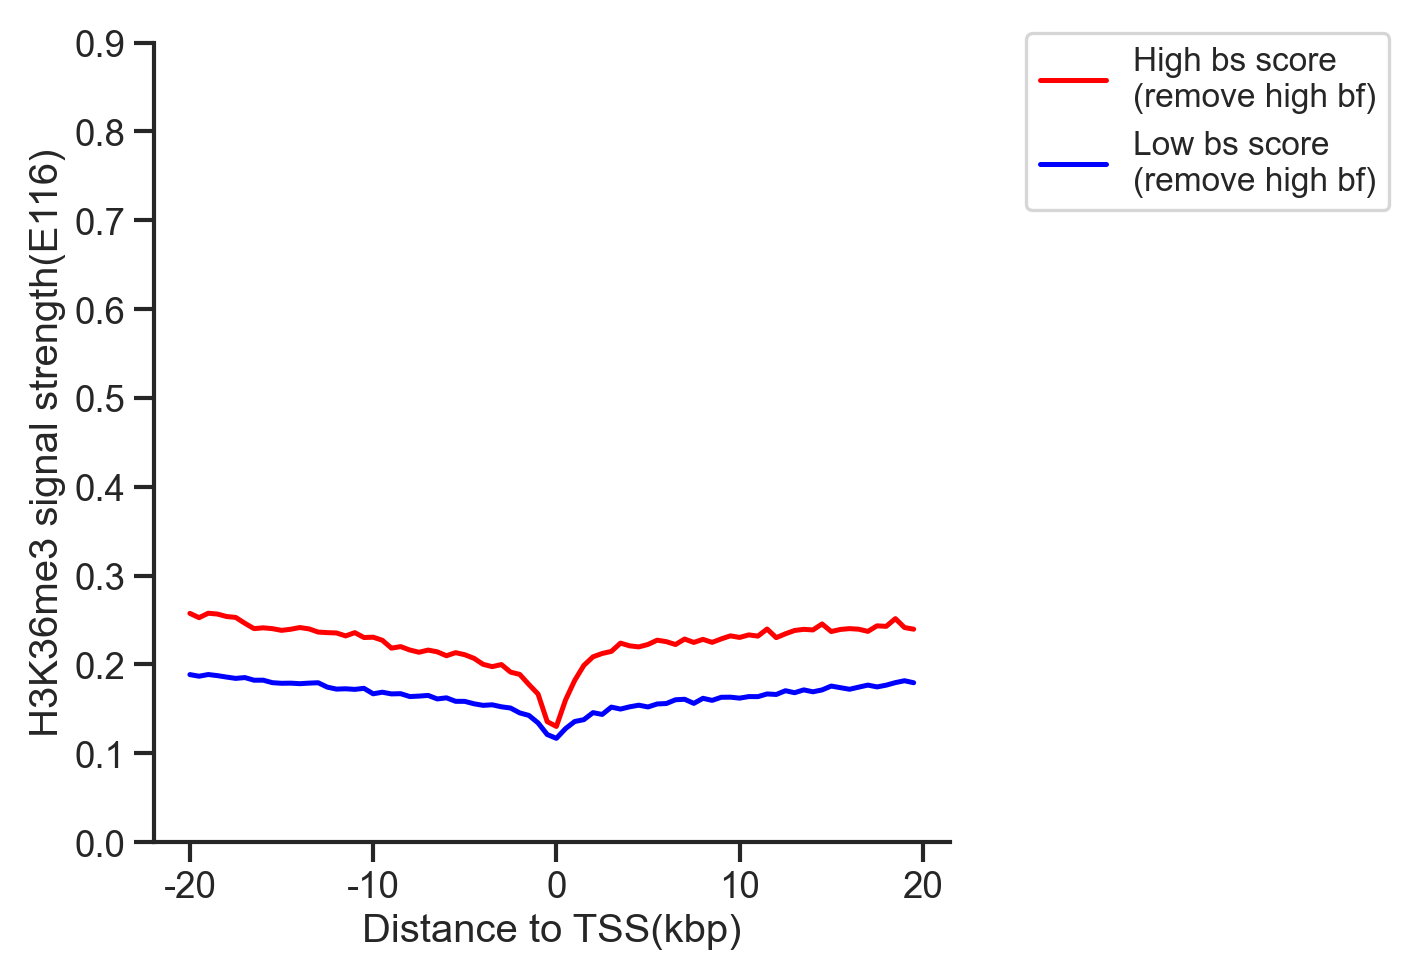

In [73]:
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.lineplot(high_marks[idx], color='red', label='High bs score \n(remove high bf)')
ax = sns.lineplot(low_marks[idx], color='blue', label='Low bs score \n(remove high bf)')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=8)

plt.yticks([i * 0.1 for i in range(0, 10)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal strength({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/figures/Figure4.d_1.eps', format='eps', bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


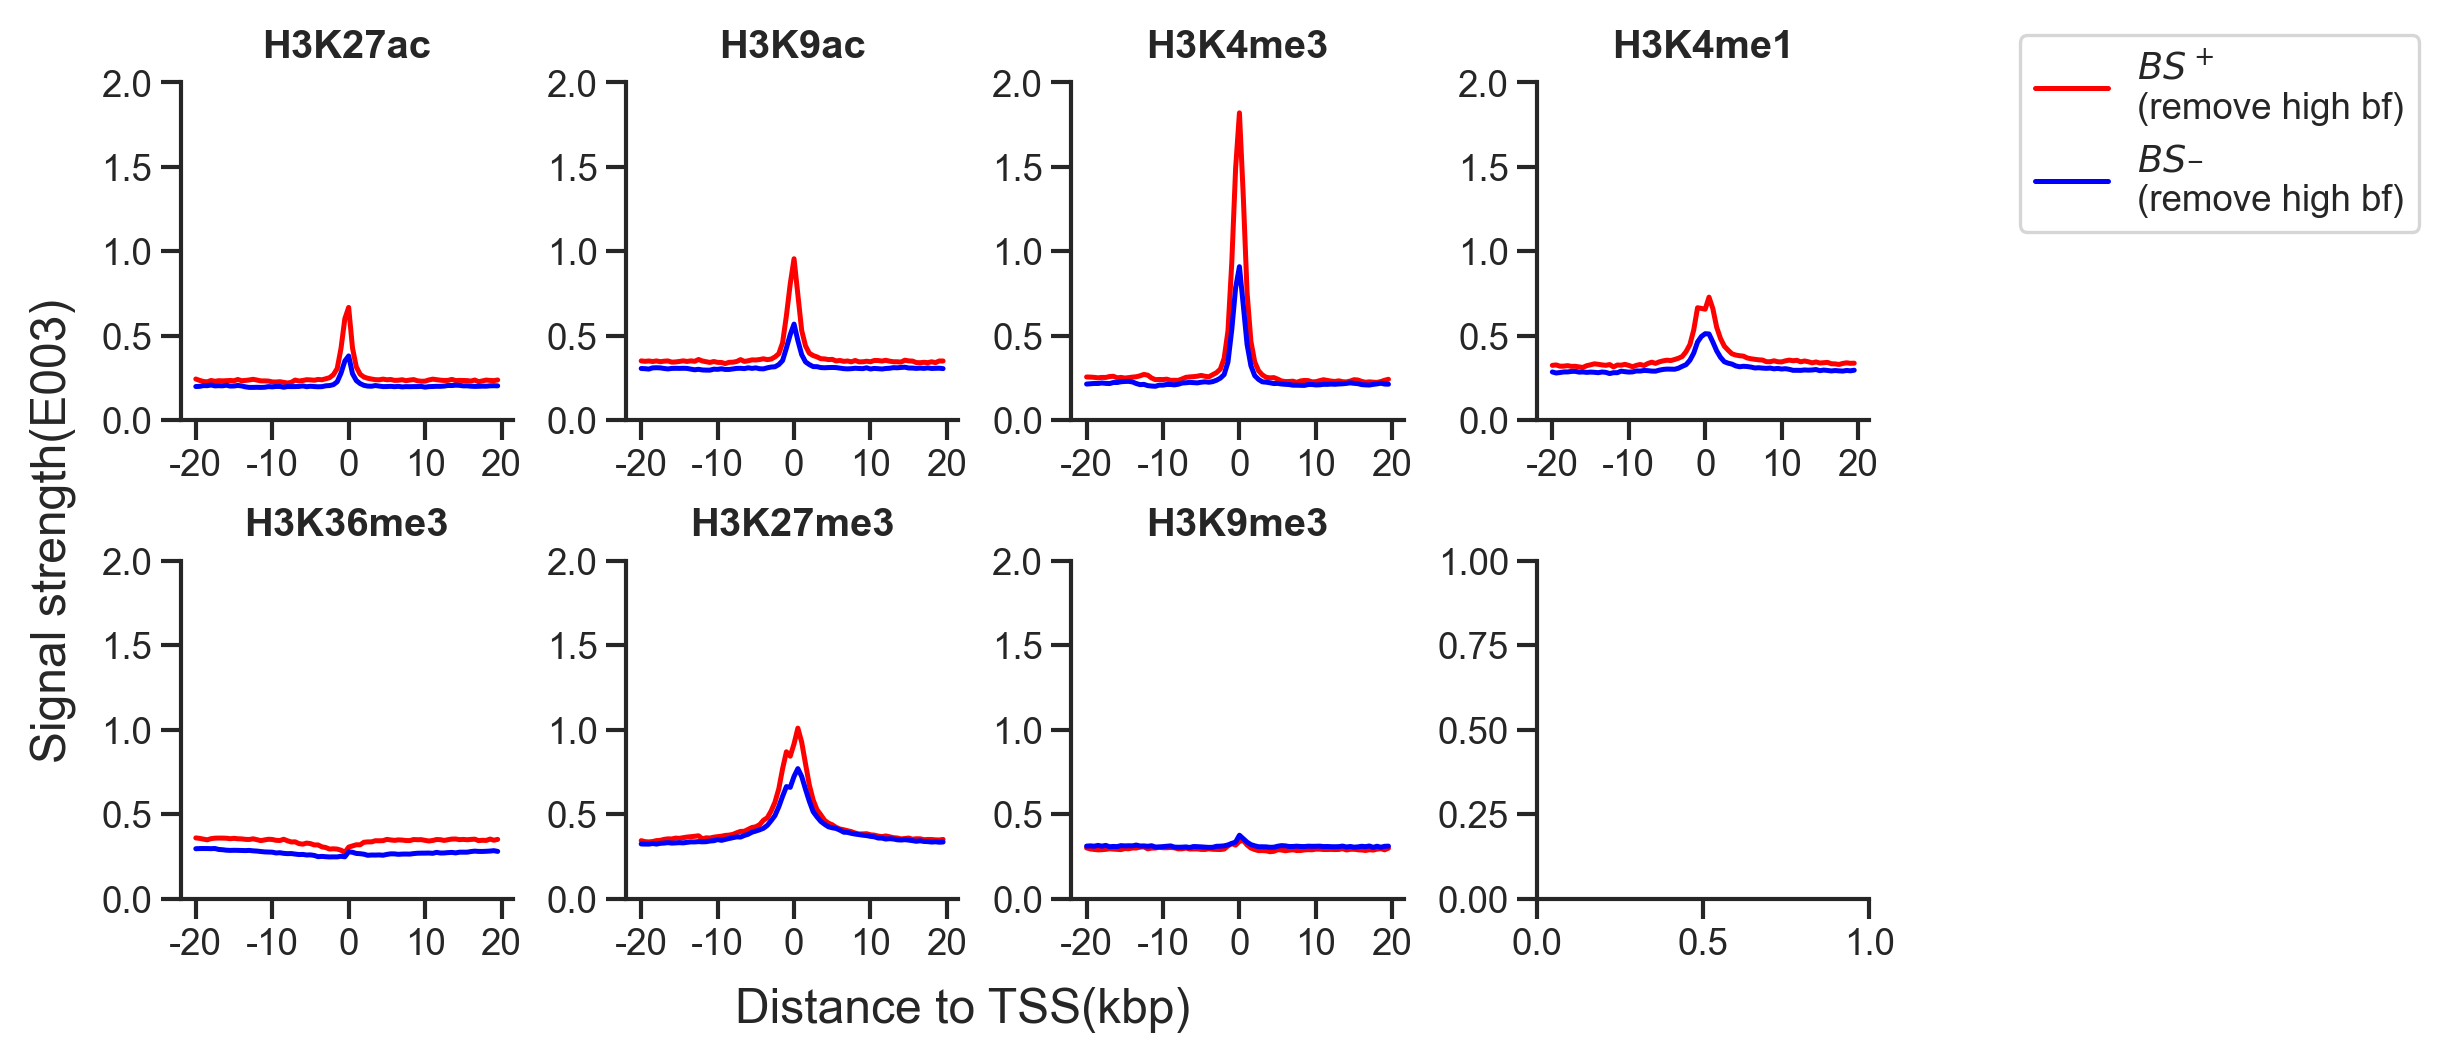

In [108]:
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BS^+$\n(remove high bf)', '$BS^\_$\n(remove high bf)']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.e_2.eps', format='eps', bbox_inches='tight')

plt.show()



### BS pred score marks strength （All BS）

In [27]:
from src.data.utils import bin_and_padding
# data = pd.read_csv(f'extra/datasets/results/{eid}_results.csv')

df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')
high_gene_ids = list(df[df['labels_marks'].isin([LABEL_BIN_MAP['High bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])][['gene_id','strand']].values)

high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)

low_gene_ids = list(df[df['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['Low bs and high bf']])][['gene_id','strand']].values)
low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


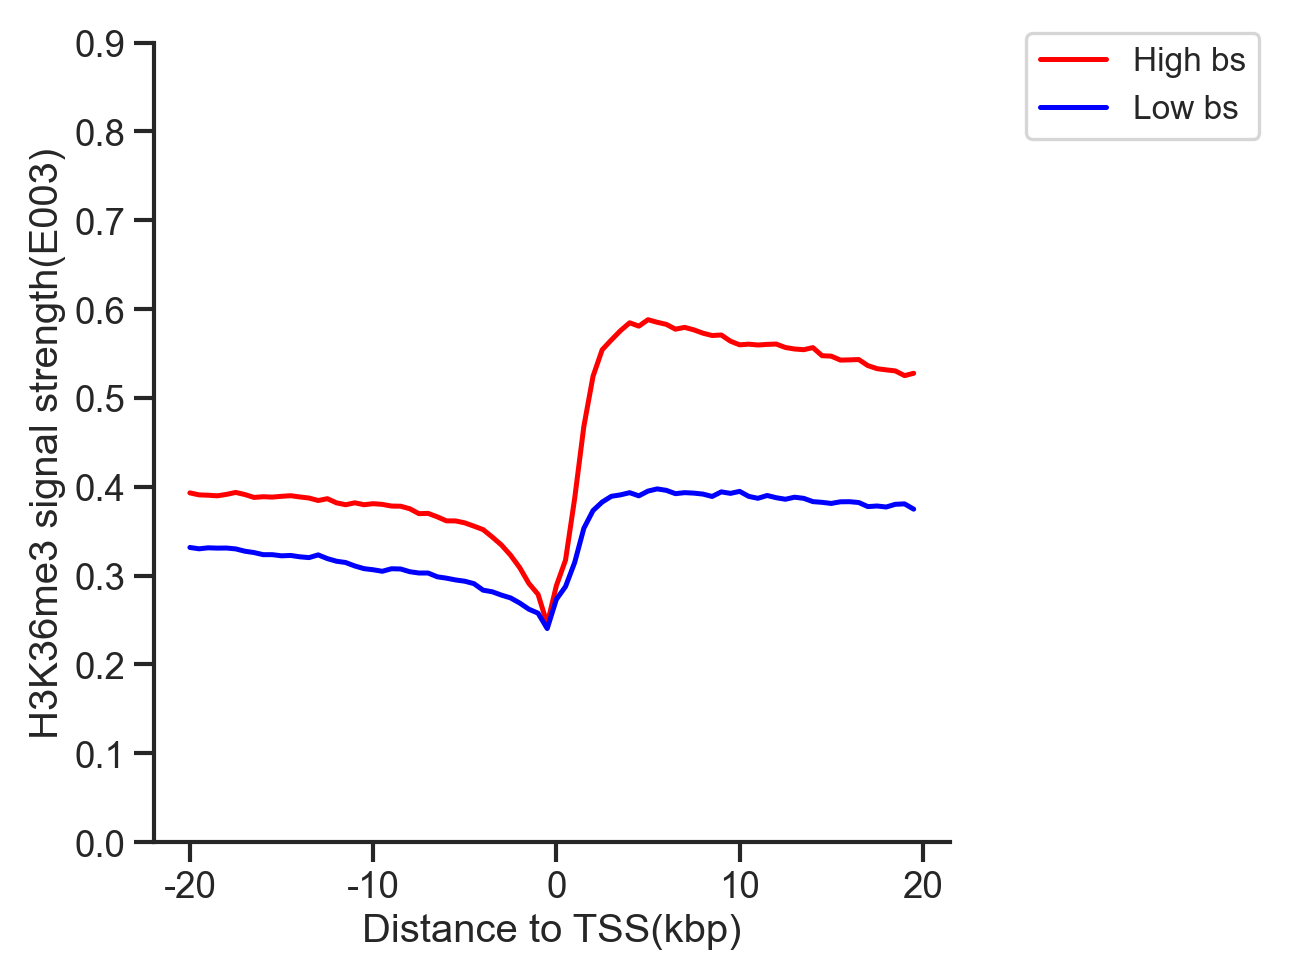

In [110]:
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.lineplot(high_marks[idx], color='red', label='High bs')
ax = sns.lineplot(low_marks[idx], color='blue', label='Low bs')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=8)

plt.yticks([i * 0.1 for i in range(0, 10)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal strength({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/figures/Figure4.d_c2.eps', format='eps', bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


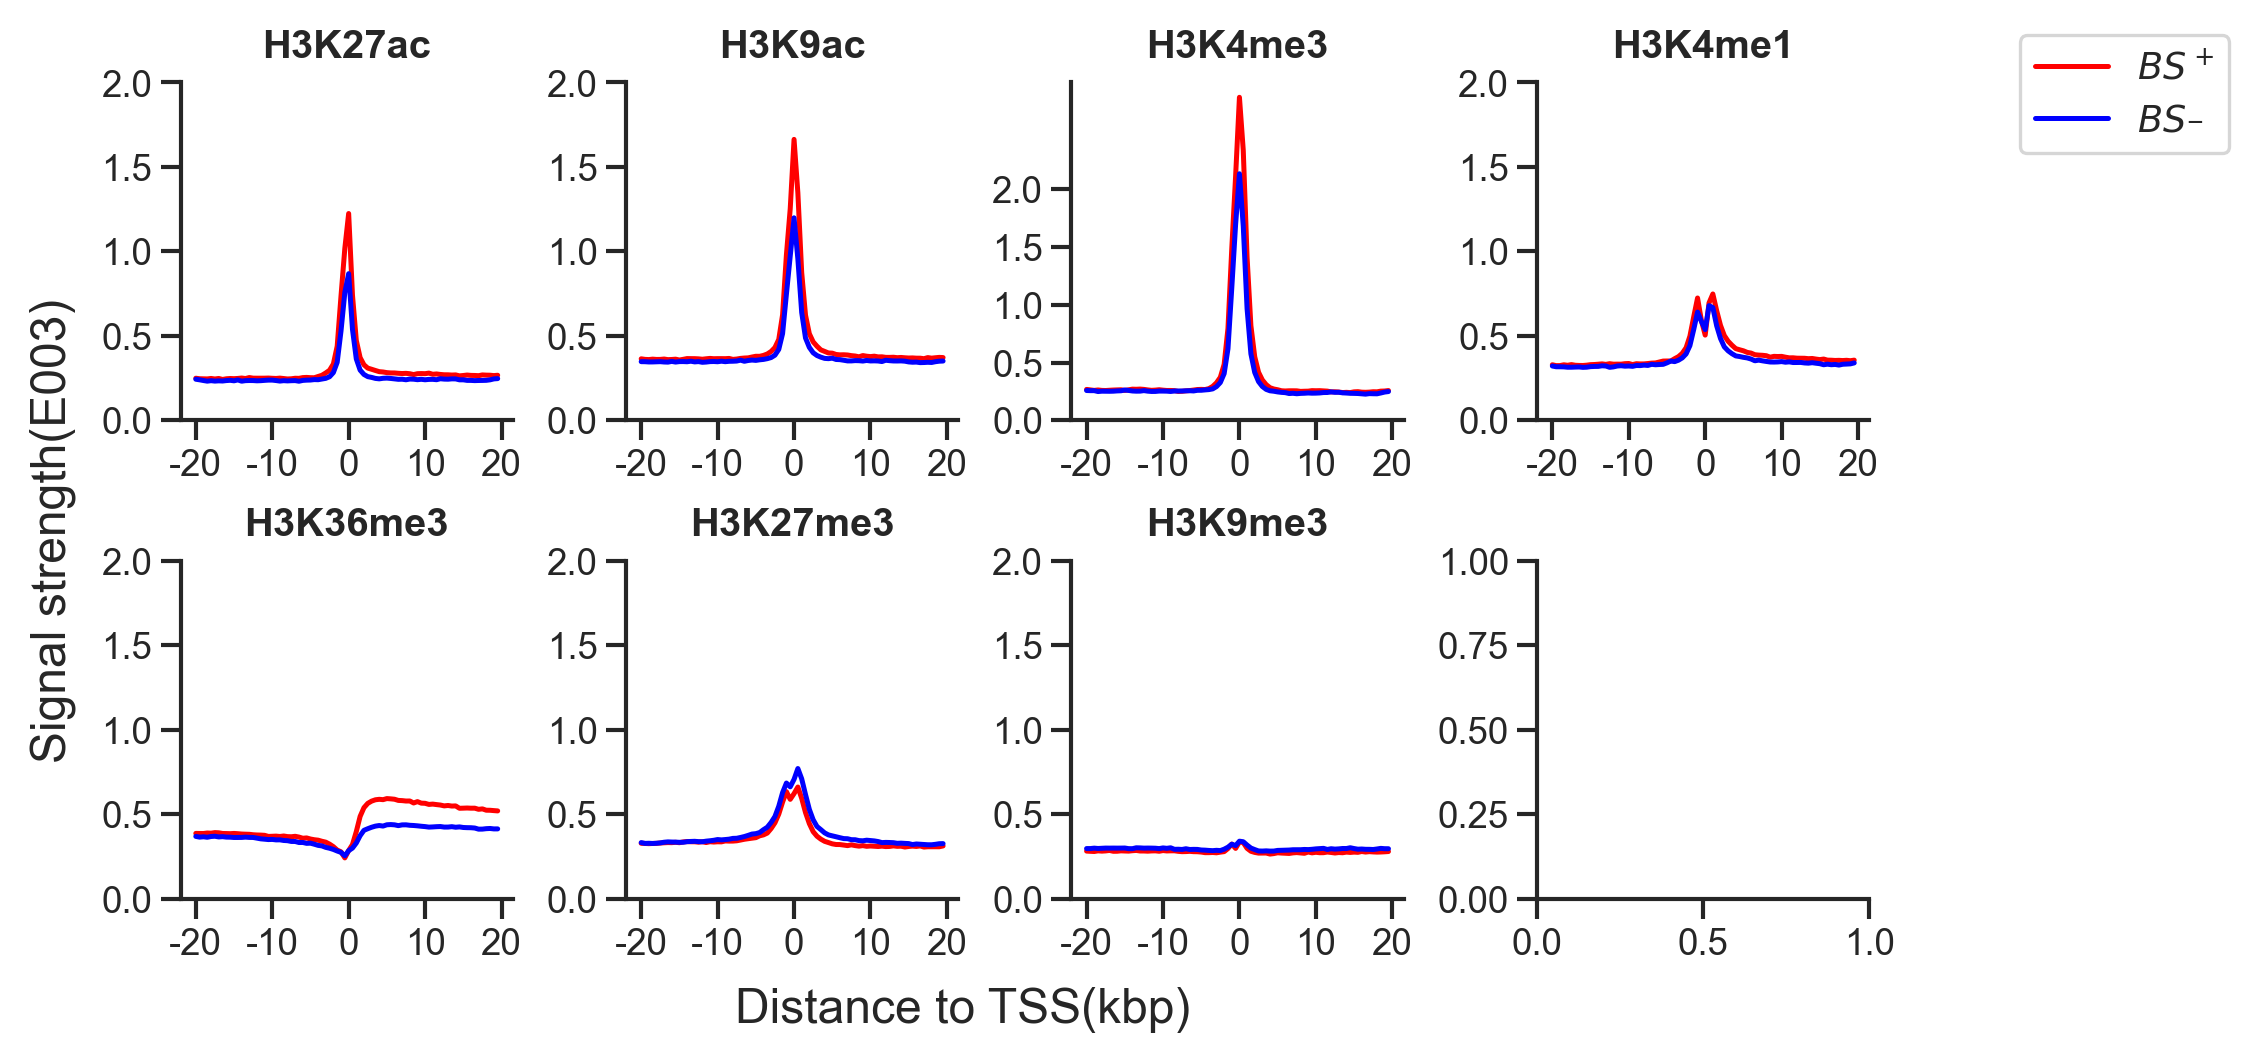

In [28]:
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BS^+$', '$BS^\_$']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.e_1.eps', format='eps', bbox_inches='tight')

plt.show()


### BF pred score marks strength

In [112]:
from src.data.utils import bin_and_padding
data = pd.read_csv(f'extra/datasets/results/{eid}_results.csv')
data1 = data[data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['Low bs and high bf']])]

df = pd.merge(data1,meta[['gene_id','strand']],how='inner',on='gene_id').sort_values(by='bf_label_score',ascending=False)

# high_gene_ids = list(df[['gene_id','strand']].values)[:100]
high_gene_ids = list(df[df['labels_marks']==LABEL_BIN_MAP['Low bs and high bf']][['gene_id','strand']].values)
high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)

# low_gene_ids = list(df[['gene_id','strand']].values)[-100:]
low_gene_ids = list(df[df['labels_marks']==LABEL_BIN_MAP['Low bs and low bf']][['gene_id','strand']].values)

low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


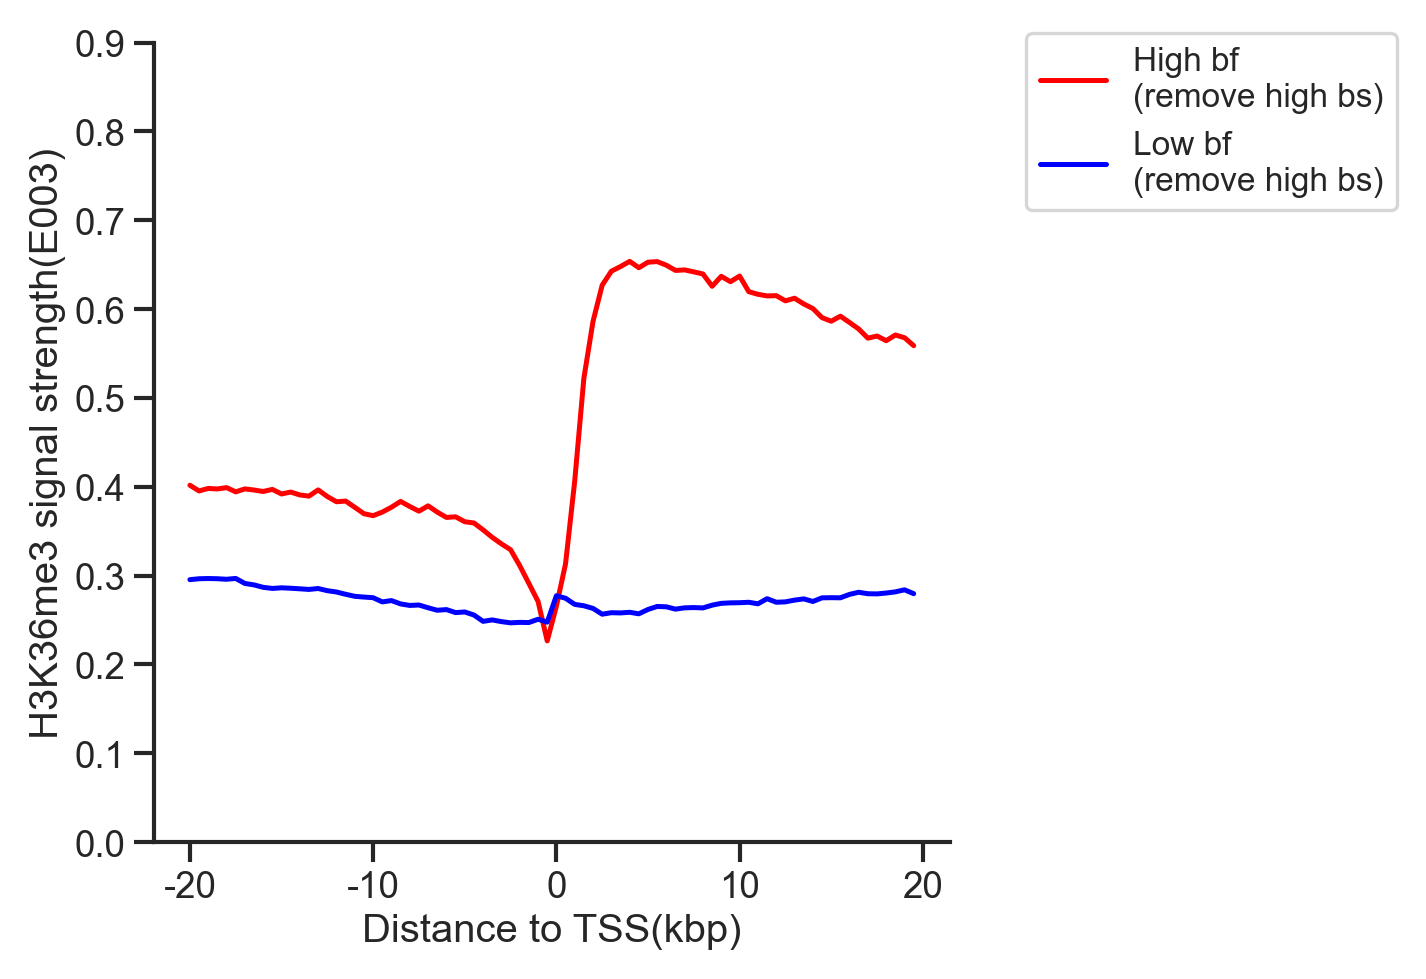

In [113]:

idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
fig, ax = plt.subplots(1,1,constrained_layout=True)
ax = sns.lineplot(high_marks[idx], color='red', label='High bf \n(remove high bs)')
ax = sns.lineplot(low_marks[idx], color='blue', label='Low bf \n(remove high bs)')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), title='', fontsize=8)

plt.yticks([i * 0.1 for i in range(0, 10)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal strength({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/figures/Figure4.d_c3.eps', format='eps', bbox_inches='tight')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


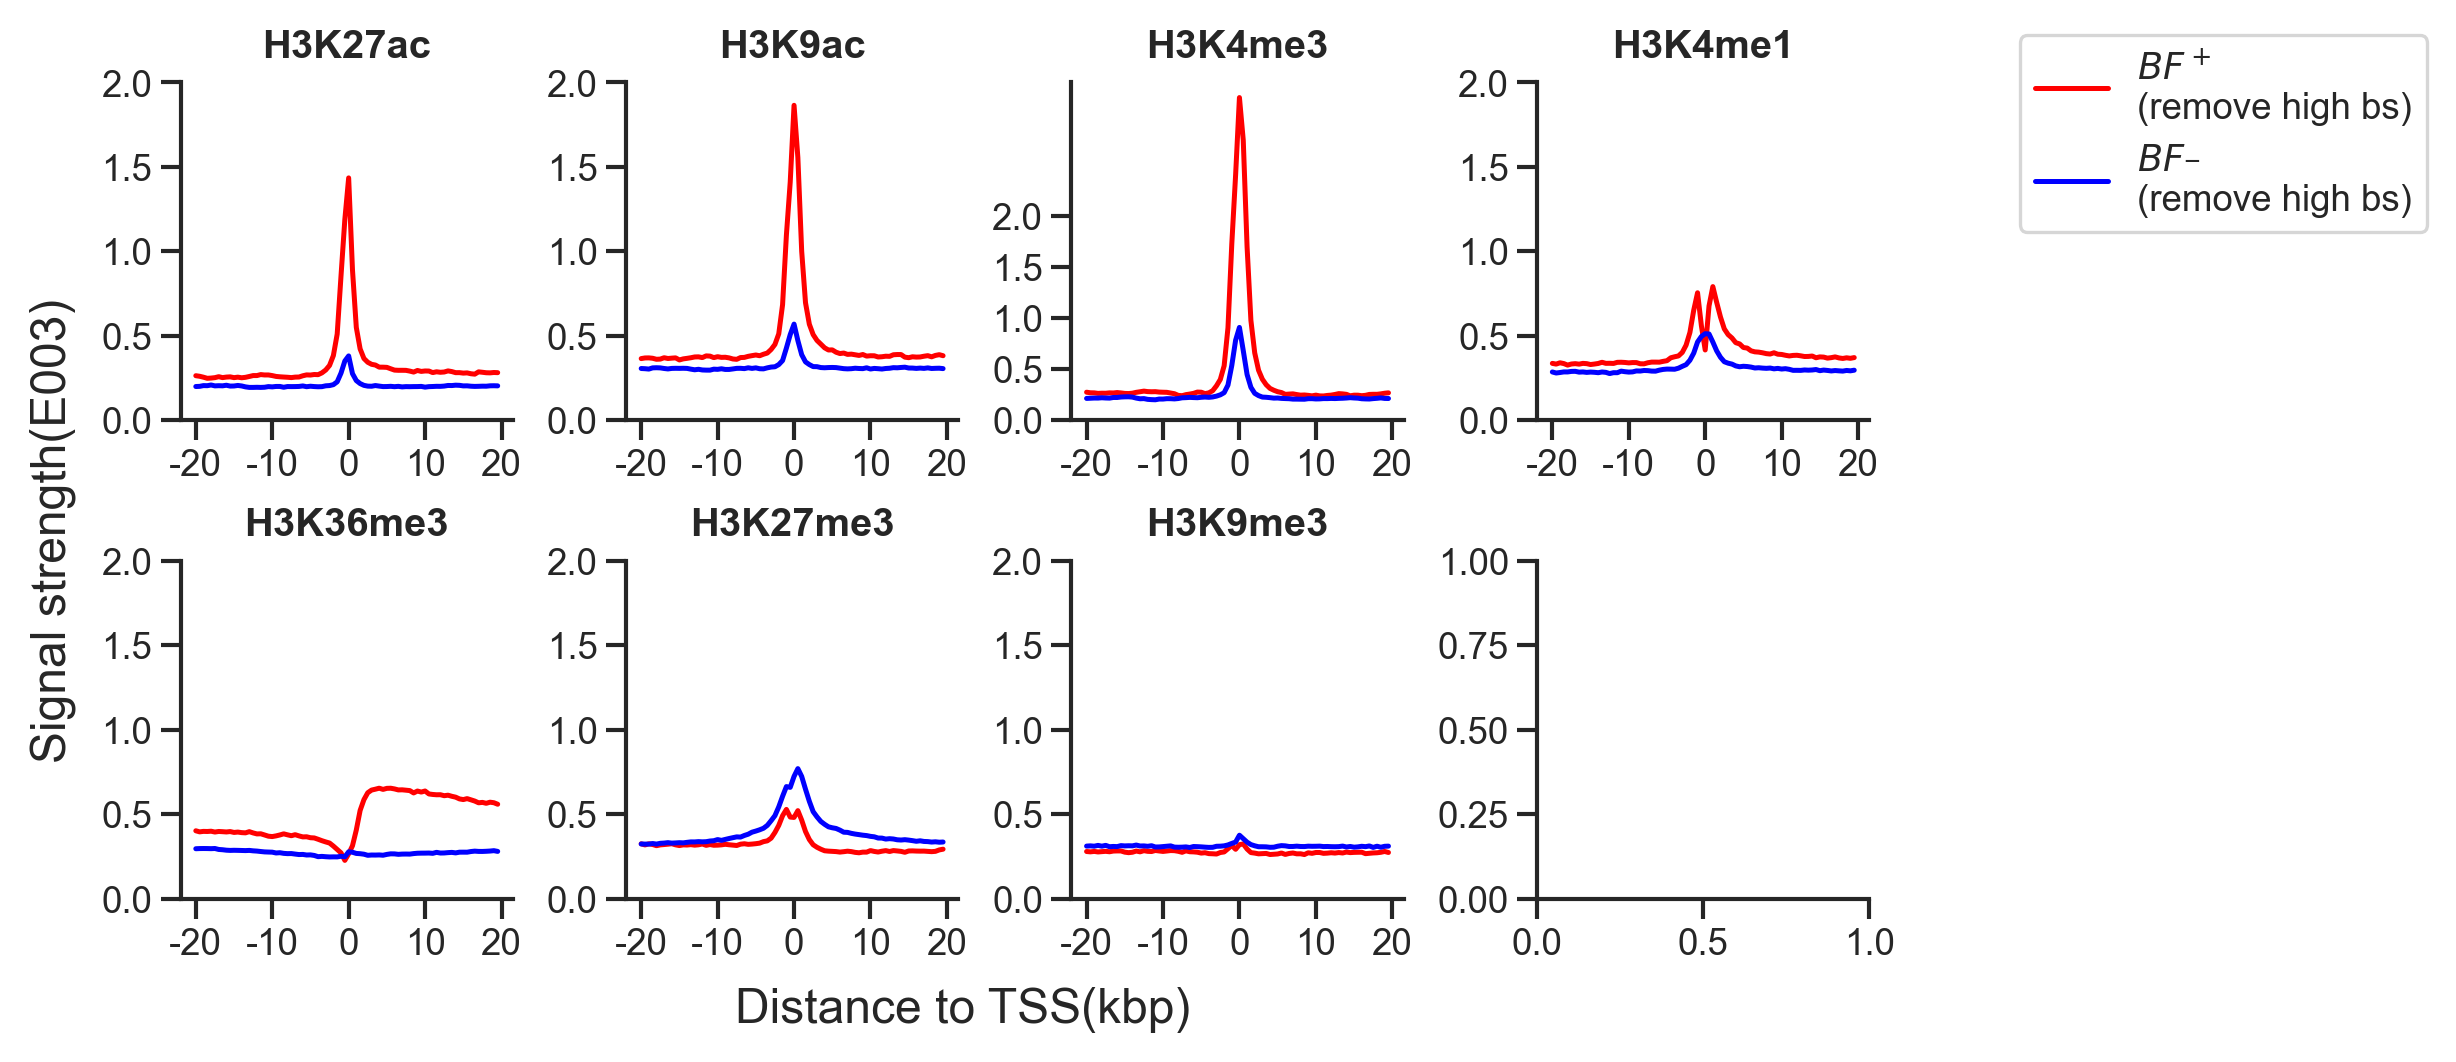

In [114]:
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BF^+$\n(remove high bs)', '$BF^\_$\n(remove high bs)']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.f_2.eps', format='eps', bbox_inches='tight')

plt.show()

# df[['gene_id']].iloc[:100].to_csv(f'extra/datasets/results/{eid}_bf_marks_genes.csv', index=False)
# df[['gene_id']].iloc[-100:].to_csv(f'extra/datasets/results/{eid}_bf_lowmarks_genes.csv', index=False)

### BF pred score marks strength （All BF）

In [115]:
from src.data.utils import bin_and_padding
data = pd.read_csv(f'extra/datasets/results/{eid}_results.csv')

df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id').sort_values(by='bf_label_score',ascending=False)
# high_gene_ids = list(df[['gene_id','strand']].values)[:100]
high_gene_ids = list(df[df['labels_marks'].isin([LABEL_BIN_MAP['Low bs and high bf'],LABEL_BIN_MAP['High bs and high bf']])][['gene_id','strand']].values)

high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)

# low_gene_ids = list(df[['gene_id','strand']].values)[-100:]
low_gene_ids = list(df[df['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and low bf']])][['gene_id','strand']].values)
low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


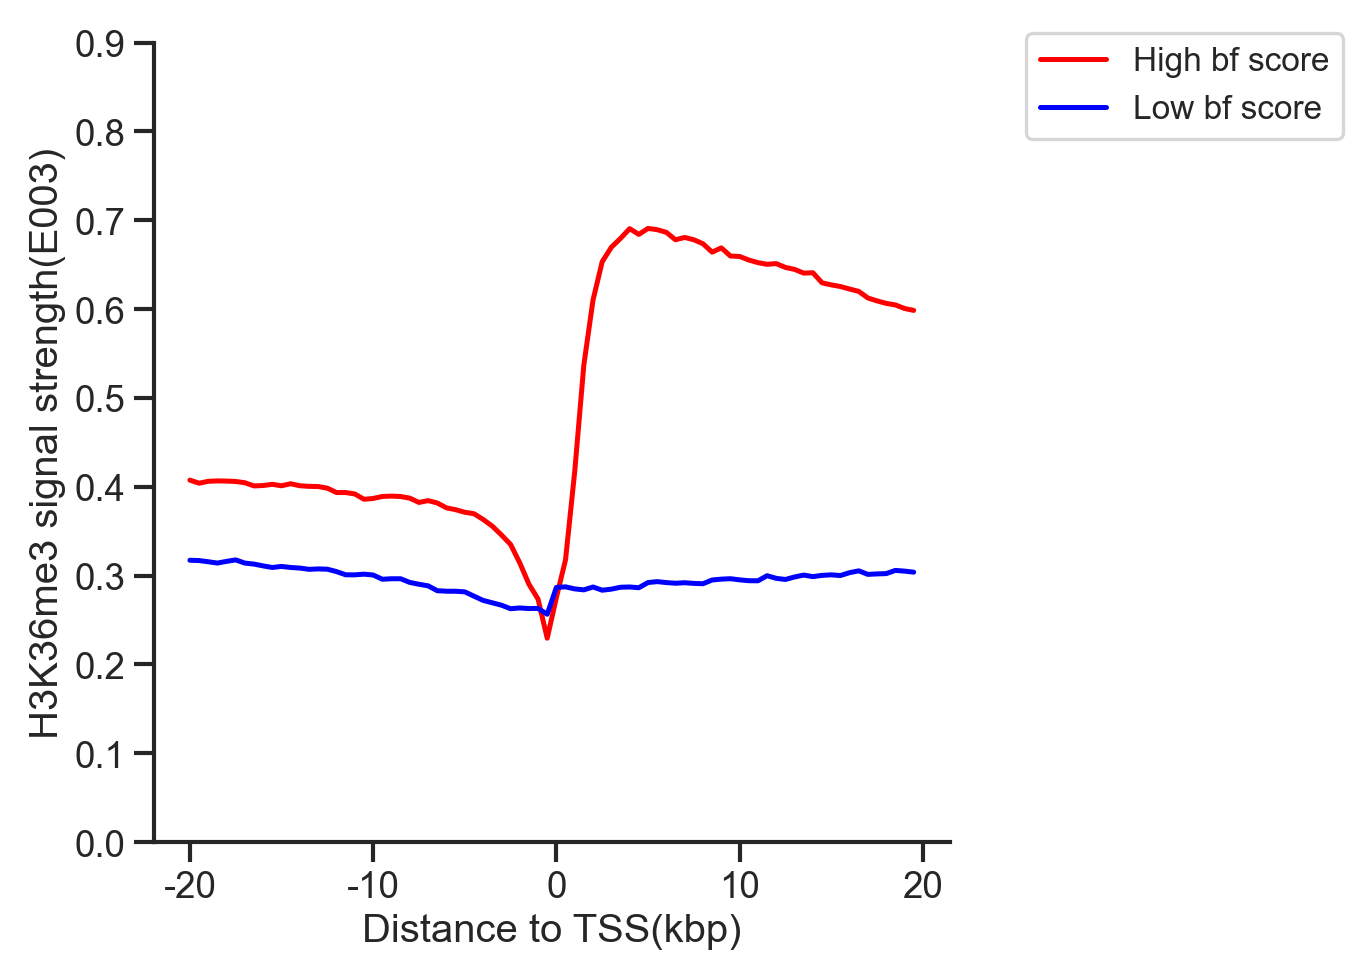

In [116]:
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.lineplot(high_marks[idx], color='red', label='High bf score')
ax = sns.lineplot(low_marks[idx], color='blue', label='Low bf score')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=8)

plt.yticks([i * 0.1 for i in range(0, 10)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal strength({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/figures/Figure4.d_c4.eps', format='eps', bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


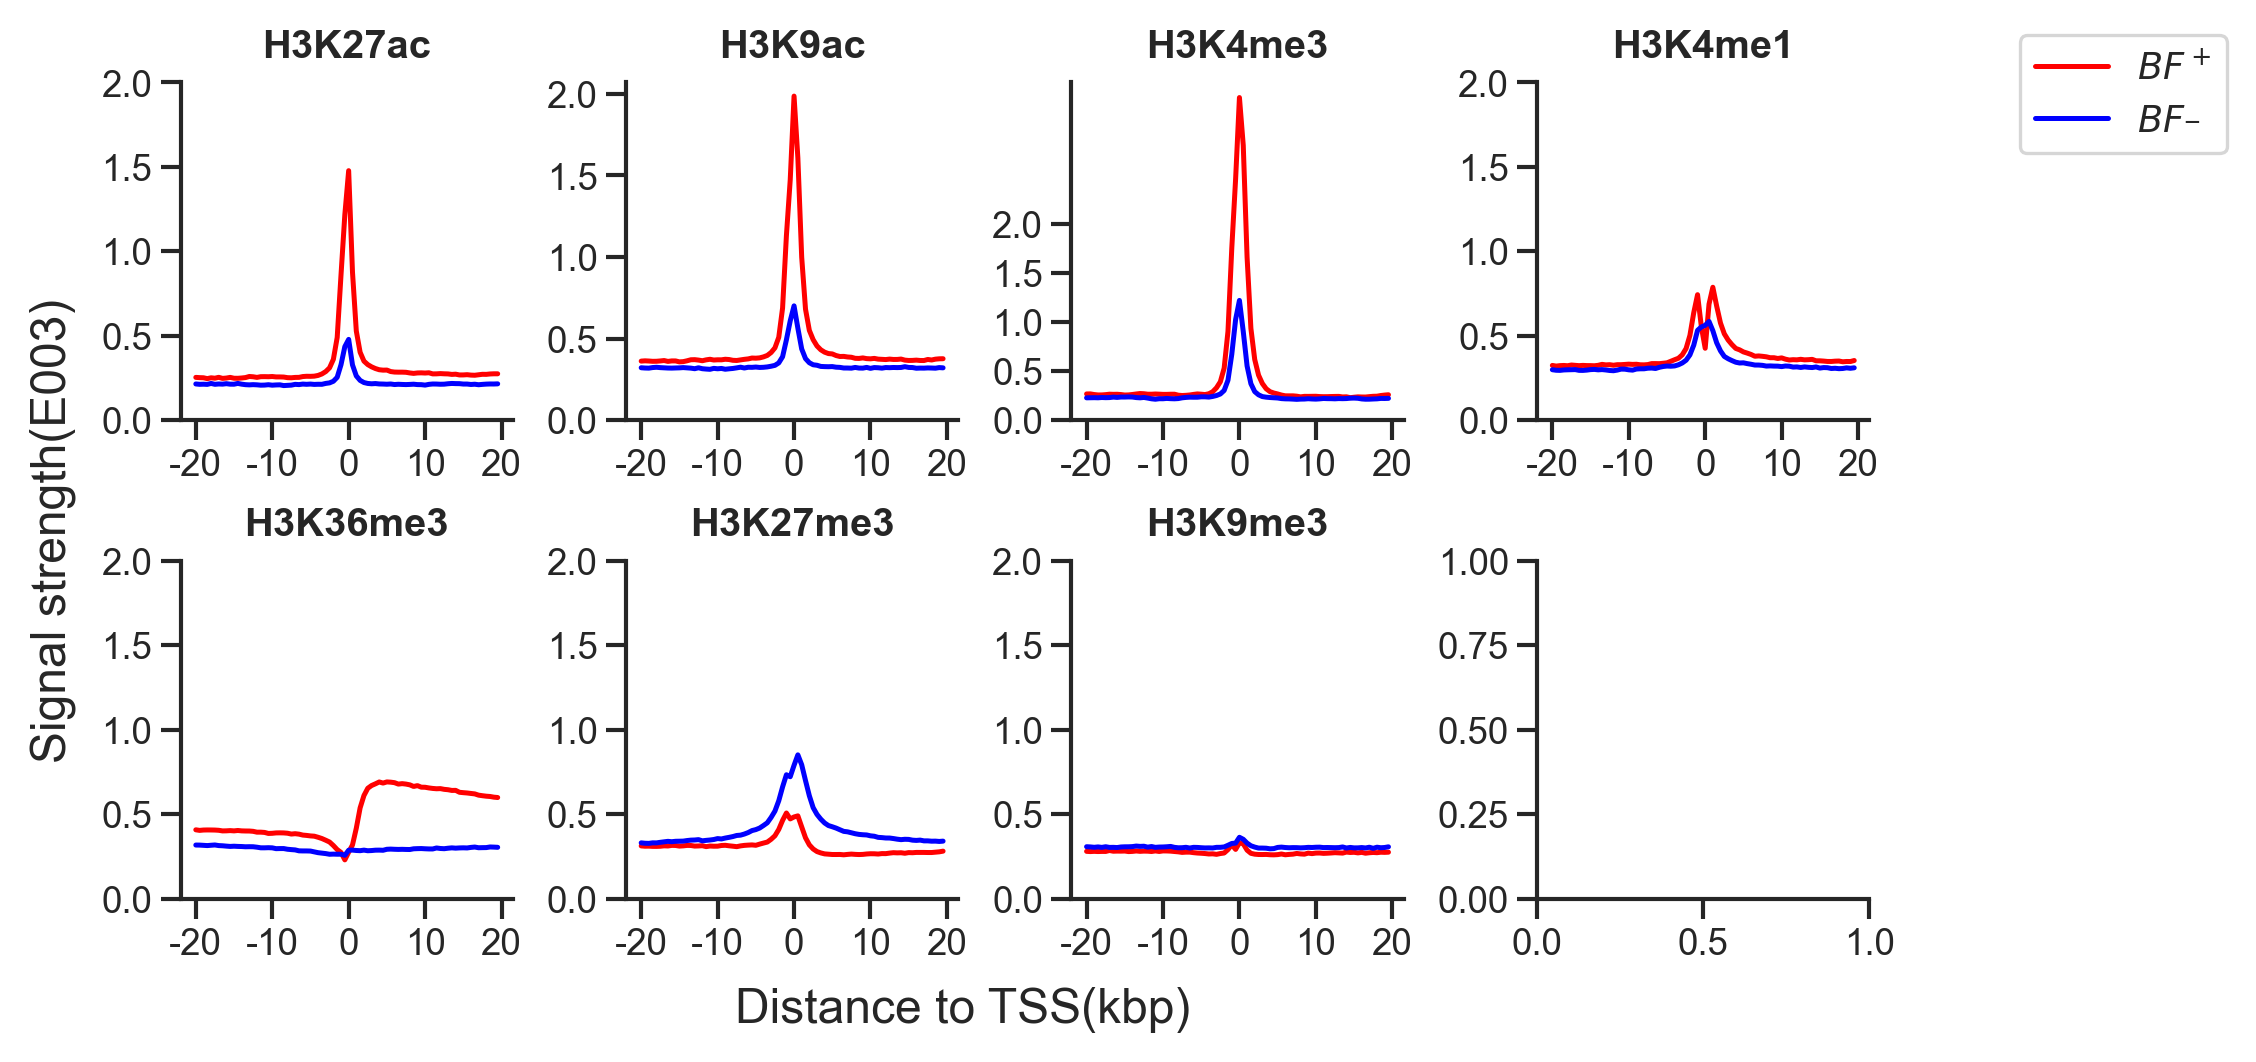

In [117]:
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BF^+$', '$BF^\_$']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.f_1.eps', format='eps', bbox_inches='tight')

plt.show()

# df[['gene_id']].iloc[:100].to_csv(f'extra/datasets/results/{eid}_bf_marks_genes.csv', index=False)
# df[['gene_id']].iloc[-100:].to_csv(f'extra/datasets/results/{eid}_bf_lowmarks_genes.csv', index=False)

## Gene analysis

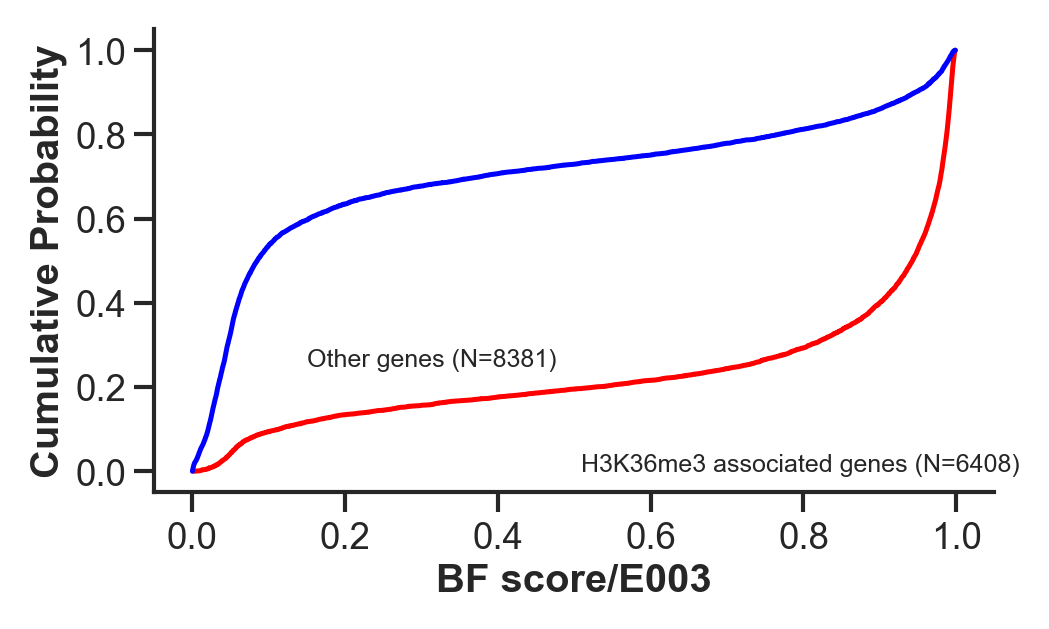

In [48]:
# H3K36me3 起到激活作用。 H3K27me3 起到抑制作用。
# eid = "E003"
remove_marks = "H3K36me3"
with_marks = pd.read_csv(f'extra/datasets/results/{eid}_predictions.csv')
without_marks = pd.read_csv(f'extra/datasets/results/{eid}_remove_{remove_marks}_predictions.csv')

df = pd.merge(with_marks[['gene_id','bf_label_score','bf_label_label']],without_marks[['gene_id','bf_label_score']],on='gene_id')
df['score_delta'] = df['bf_label_score_y'] - df['bf_label_score_x']
# df = df[(df['bf_label_label'] == 1)]
df1 = df[(df['score_delta'] < 0)]


#  'H3K27me3':
df1 = pd.merge(df,h3k36me3[['gene_id']],on='gene_id')

observed_data_1 = list(df1['bf_label_score_x'])
 
# Sort the data
sorted_data_1 = np.sort(observed_data_1)

# Calculate cumulative probabilities
cdf_1 = np.arange(1, len(sorted_data_1)+1) / len(sorted_data_1)

df3 = df[~df['gene_id'].isin(df1['gene_id'])]
# Example: Observed data sampled from a normal distribution
observed_data_3 = list(df3['bf_label_score_x'])

# Sort the data
sorted_data_3 = np.sort(observed_data_3)

# Calculate cumulative probabilities
cdf_3 = np.arange(1, len(sorted_data_3)+1) / len(sorted_data_3)

# Plot the empirical CDF
# plt.figure(figsize=(8, 6))
plt.plot(sorted_data_1, cdf_1, label=f'{remove_marks} genes', color='red')
# plt.plot(sorted_data_2, cdf_2, label=f'{remove_marks} genes', color='black')
plt.plot(sorted_data_3, cdf_3, label='Other genes CDF', color='blue')


# Customize the plot
plt.xlabel(f'BF score/{eid}')
plt.ylabel('Cumulative Probability')
# plt.title('Empirical CDF vs Theoretical CDF')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.legend().remove()
plt.tight_layout()
plt.text(0.15,0.25, f"Other genes (N={len(observed_data_3)})",fontdict={'size':6})
# plt.text(0.15,0.2, f"{remove_marks} associated genes (remove {remove_marks}, {len(observed_data_2)})",fontdict={'size':6})
plt.text(0.5,0.0, f" {remove_marks} associated genes (N={len(observed_data_1)})",fontdict={'size':6})
plt.show()

df1.to_csv(f"extra/datasets/results/{eid}_{remove_marks}_associated_genes.csv",index=False)

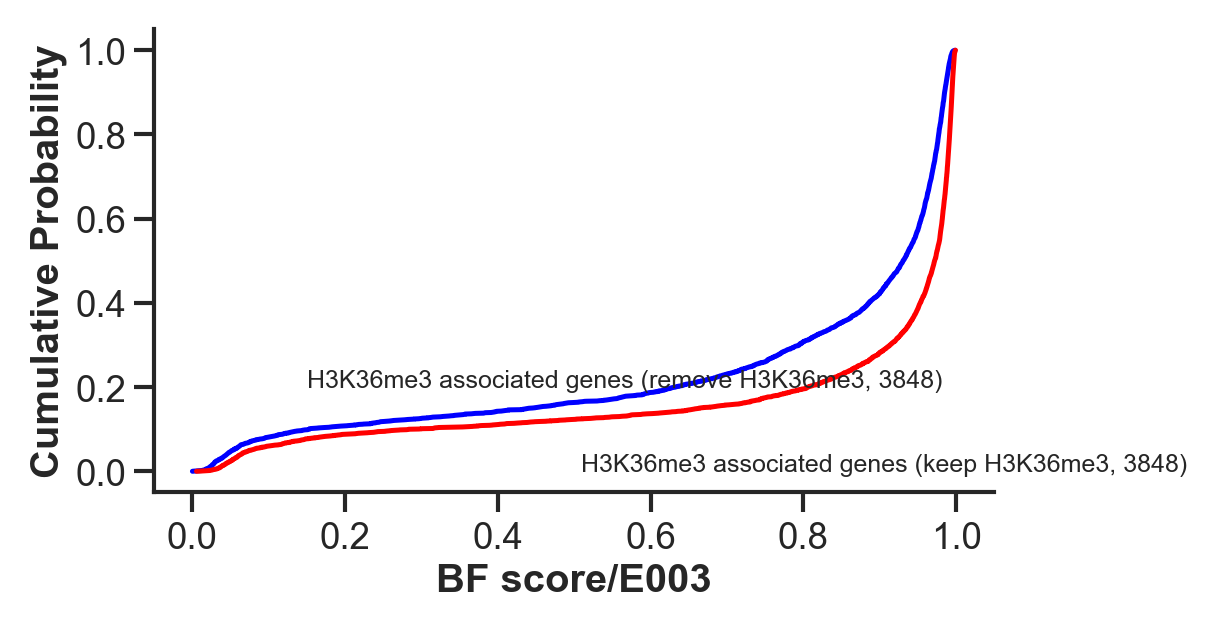

In [49]:
# H3K36me3 起到激活作用。 H3K27me3 起到抑制作用。

remove_marks = "H3K36me3"
with_marks = pd.read_csv(f'extra/datasets/results/{eid}_predictions.csv')
without_marks = pd.read_csv(f'extra/datasets/results/{eid}_remove_{remove_marks}_predictions.csv')

df = pd.merge(with_marks[['gene_id','bf_label_score','bf_label_label']],without_marks[['gene_id','bf_label_score']],on='gene_id')
df['score_delta'] = df['bf_label_score_y'] - df['bf_label_score_x']
# df = df[(df['bf_label_label'] == 1)]
df1 = df[(df['score_delta'] < 0)]



df1 = pd.merge(df1,h3k36me3[['gene_id']],on='gene_id')

observed_data_1 = list(df1['bf_label_score_y'])
 
# Sort the data
sorted_data_1 = np.sort(observed_data_1)

# Calculate cumulative probabilities
cdf_1 = np.arange(1, len(sorted_data_1)+1) / len(sorted_data_1)


df2 = pd.merge(df1,h3k36me3[['gene_id']],on='gene_id')

observed_data_2 = list(df2['bf_label_score_x'])
 
# Sort the data
sorted_data_2 = np.sort(observed_data_2)

# Calculate cumulative probabilities
cdf_2 = np.arange(1, len(sorted_data_2)+1) / len(sorted_data_2)


# Plot the empirical CDF
# plt.figure(figsize=(8, 6))
plt.plot(sorted_data_1, cdf_1, label=f'{remove_marks} genes', color='blue')
plt.plot(sorted_data_2, cdf_2, label=f'{remove_marks} genes', color='red')


# Customize the plot
plt.xlabel(f'BF score/{eid}')
plt.ylabel('Cumulative Probability')
# plt.title('Empirical CDF vs Theoretical CDF')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.legend().remove()
plt.tight_layout()
plt.text(0.15,0.2, f"{remove_marks} associated genes (remove {remove_marks}, {len(observed_data_2)})",fontdict={'size':6})
plt.text(0.5,0.0, f" {remove_marks} associated genes (keep {remove_marks}, {len(observed_data_1)})",fontdict={'size':6})
plt.show()

df1.to_csv(f"extra/datasets/results/{eid}_{remove_marks}_associated_genes.csv",index=False)

In [95]:
high_marks = pd.read_csv(f'extra/datasets/results/{eid}_bf_highmarks_genes.csv')
high_marks

,gene_id
0,ENSG00000005007
1,ENSG00000213079
2,ENSG00000095015
3,ENSG00000150457
4,ENSG00000141026
...,...
95,ENSG00000105723
96,ENSG00000141219
97,ENSG00000006194
98,ENSG00000198863


In [96]:
high_marks = pd.read_csv(f'extra/datasets/results/{eid}_bf_highmarks_genes.csv')


df1.sort_values(by='score_delta',ascending=True).to_csv('temp.csv',index=False)

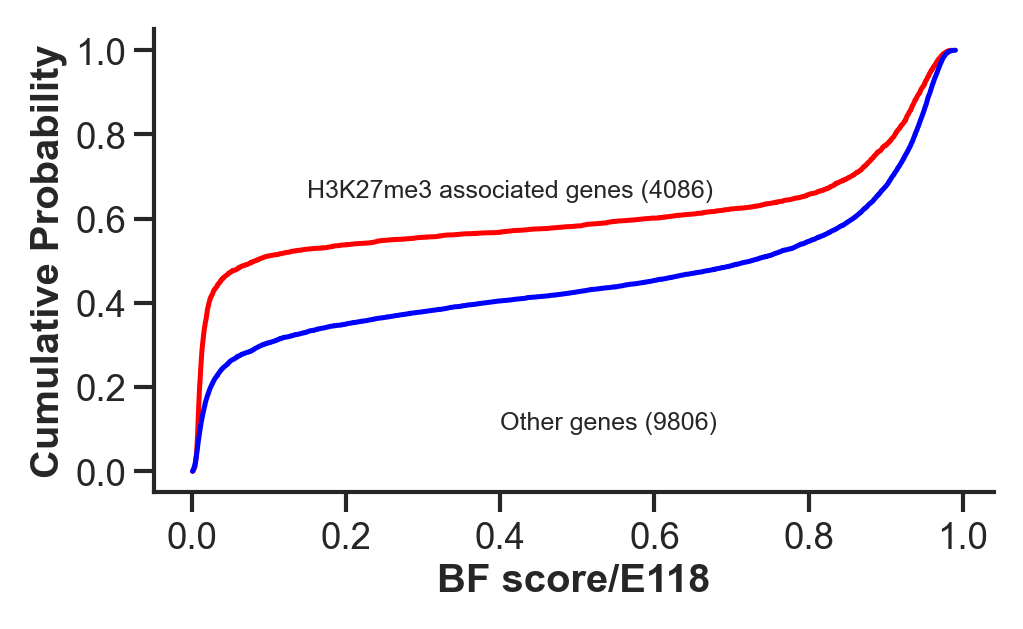

In [97]:
remove_marks = "H3K27me3"
with_marks = pd.read_csv(f'extra/datasets/results/{eid}_predictions.csv')
without_marks = pd.read_csv(f'extra/datasets/results/{eid}_remove_{remove_marks}_predictions.csv')

df = pd.merge(with_marks[['gene_id','bf_label_score','bf_label_label']],without_marks[['gene_id','bf_label_score']],on='gene_id')
df['score_delta'] = df['bf_label_score_y'] - df['bf_label_score_x']
# df = df[(df['bf_label_label'] == 0)]
df1 = df[(df['score_delta'] > 0)]


#  'H3K27me3':
df1 = pd.merge(df1,h3k27me3[['gene_id']],on='gene_id')

observed_data_1 = list(df1['bf_label_score_x'])
 
# Sort the data
sorted_data_1 = np.sort(observed_data_1)

# Calculate cumulative probabilities
cdf_1 = np.arange(1, len(sorted_data_1)+1) / len(sorted_data_1)


df3 = df[~df['gene_id'].isin(df1['gene_id'])]
# Example: Observed data sampled from a normal distribution
observed_data_3 = list(df3['bf_label_score_y'])

# Sort the data
sorted_data_3 = np.sort(observed_data_3)

# Calculate cumulative probabilities
cdf_3 = np.arange(1, len(sorted_data_3)+1) / len(sorted_data_3)

# Plot the empirical CDF
# plt.figure(figsize=(8, 6))
plt.plot(sorted_data_1, cdf_1, label=f'{remove_marks} genes', color='red')
# plt.plot(sorted_data_2, cdf_2, label=f'{remove_marks} genes', color='blue')
plt.plot(sorted_data_3, cdf_3, label='Other genes CDF', color='blue')


# Customize the plot
plt.xlabel(f'BF score/{eid}')
plt.ylabel('Cumulative Probability')
# plt.title('Empirical CDF vs Theoretical CDF')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.legend().remove()
plt.tight_layout()
plt.text( 0.4,0.1,f"Other genes ({len(observed_data_3)})",fontdict={'size':6})
plt.text(0.15,0.65, f"{remove_marks} associated genes ({len(observed_data_1)})",fontdict={'size':6})
plt.show()

##  cell type specific

In [29]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
with open('extra/datasets/benchmark/cell_type_specific.csv','w') as w:
    line = ['bs_auc','bf_auc','fold','eid']
    w.write('\t'.join(line) + '\n')
    for fold in [0,1,2,3]:
        for eid in eids:
            checkpoints = f'checkpoints/{eid}.{fold}.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            bs_auc = ckpt['bs_label_val_auc']
            bf_auc = ckpt['bf_label_val_auc']
            line = [str(bs_auc),str(bf_auc),str(fold), eid]
            w.write('\t'.join(line) + '\n')
        
    
cell_type_agnostic = pd.read_csv('extra/datasets/results/valid.csv',sep='\t')
cell_type_agnostic['cell_type'] = 'Agnostic model'
cell_type_specific = pd.read_csv('extra/datasets/benchmark/cell_type_specific.csv',sep='\t')
cell_type_specific['cell_type'] = 'Specific model'
df = pd.concat([cell_type_specific,cell_type_agnostic], axis=0)
bf_df = df[['bf_auc','fold','eid','cell_type']]
bf_df.columns = ['auc','fold','eid','cell_type']
bf_df['cell_type'] = 'bf_' + bf_df['cell_type'] 
bs_df = df[['bs_auc','fold','eid','cell_type']]
bs_df.columns = ['auc','fold','eid','cell_type']
bs_df['cell_type'] = 'bs_' + bs_df['cell_type'] 

df_melt = pd.concat([bs_df,bf_df], axis=0)
df_melt


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/1265445771.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bf_df['cell_type'] = 'bf_' + bf_df['cell_type']
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_28829/1265445771.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bs_df['cell_type'] = 'bs_' + bs_df['cell_type']


,auc,fold,eid,cell_type
0,74.377029,0,E003,bs_Specific model
1,70.481940,0,E118,bs_Specific model
2,80.175793,0,E116,bs_Specific model
3,72.948594,1,E003,bs_Specific model
4,74.213351,1,E118,bs_Specific model
5,80.326466,1,E116,bs_Specific model
6,74.992846,2,E003,bs_Specific model
7,72.923188,2,E118,bs_Specific model
8,80.983747,2,E116,bs_Specific model
9,72.452844,3,E003,bs_Specific model


### cell type specific Model Vs cell type agnostic Model

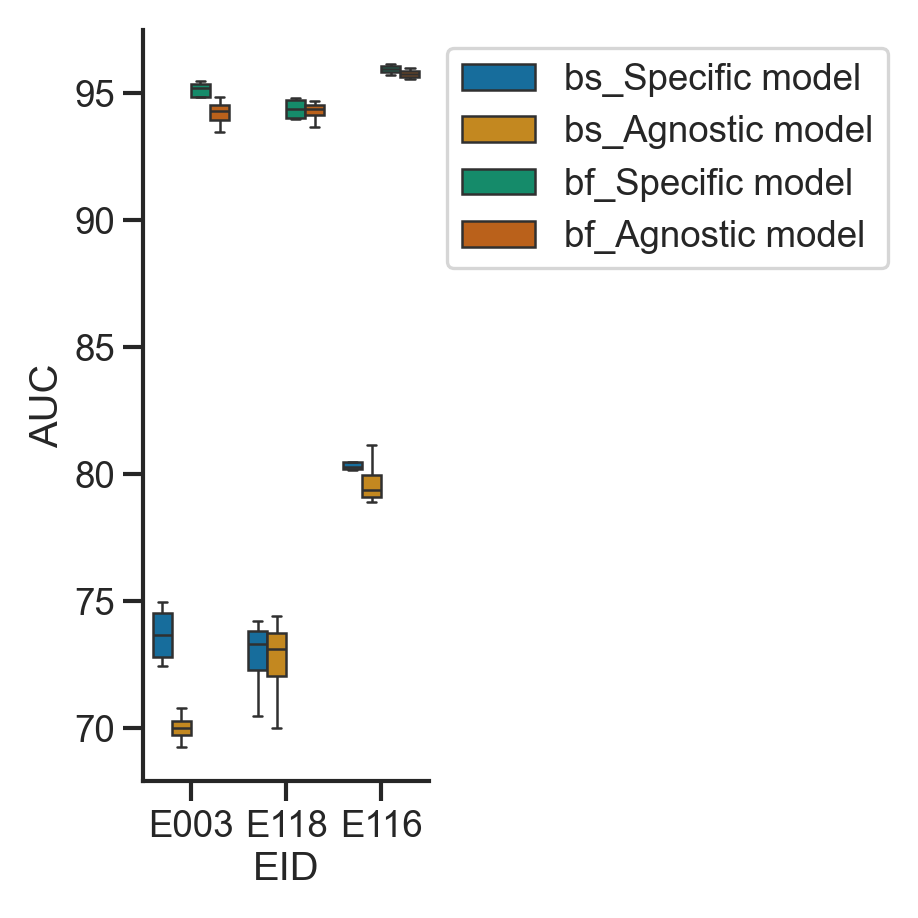

In [30]:
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

sns.boxplot(data=df_melt, x='eid',y='auc',hue='cell_type',fliersize=0,linewidth=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.ylabel('AUC')
plt.xlabel('EID')
# Show the plot
plt.show()

### BS cell type specific Model

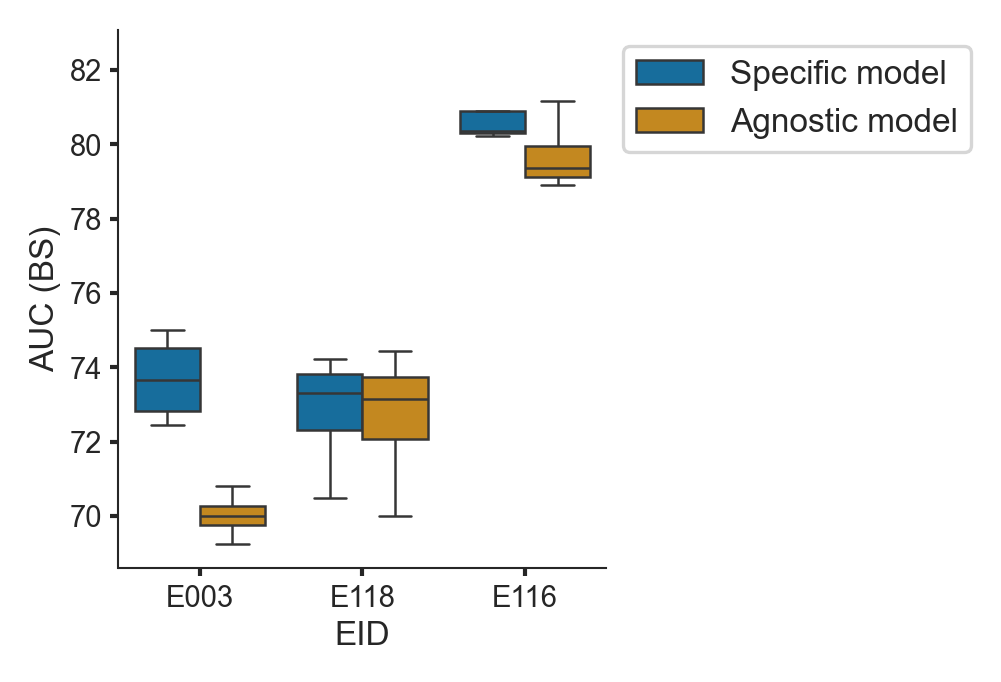

In [11]:

# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
ax = sns.boxplot(data=df, x='eid',y='bs_auc',hue='cell_type',fliersize=0, linewidth=0.6)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
ax.set_ylabel('AUC (BS)')
ax.set_xlabel('EID')
# Show the plot
plt.show()

### BF cell type specific Model

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


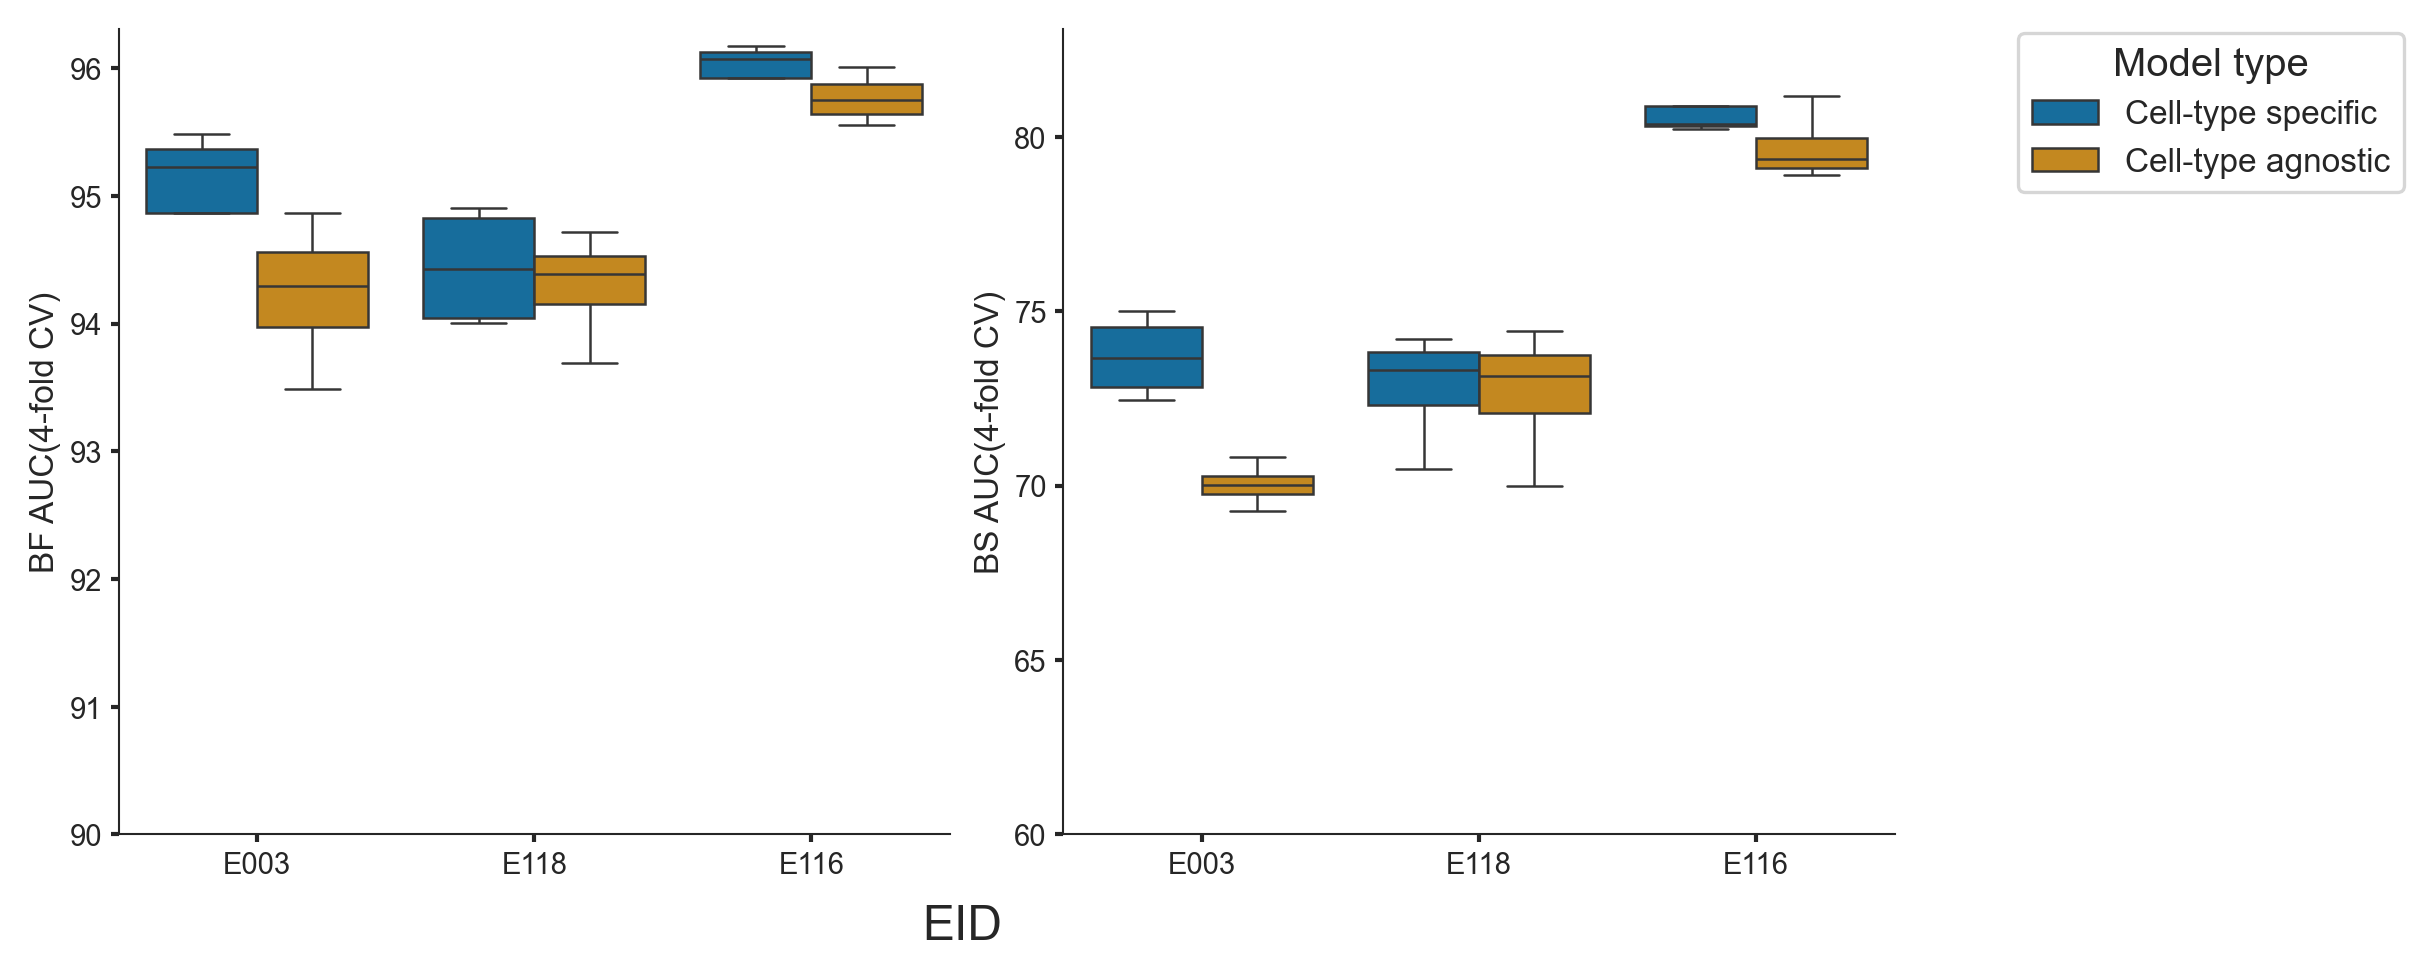

In [12]:

# 设置为 colorblind 调色板
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(16/2.54, 8/2.54))

# sns.set_palette("colorblind")
# sns.set_context("paper") 
sns.boxplot(data=df, x='eid',y='bf_auc',hue='cell_type',fliersize=0, linewidth=0.6,ax=ax[0])
sns.boxplot(data=df, x='eid',y='bs_auc',hue='cell_type',fliersize=0, linewidth=0.6,ax=ax[1])
ax[0].set_ylabel("BF AUC(4-fold CV)")
ax[1].set_ylabel("BS AUC(4-fold CV)")
fig.supxlabel('EID')
handles, labels = ax[0].get_legend_handles_labels()
labels = [ "Cell-type specific","Cell-type agnostic"]
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xlabel('')

ax[0].set_ylim(ymin=90)
ax[1].set_ylim(ymin=60)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), title='Model type', fontsize=8)
plt.savefig('extra/datasets/figures/Figure2.b.eps', format='eps', bbox_inches='tight')

# Show the plot
plt.show()

## Abelation Experiments

In [5]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
with open('extra/datasets/results/ablation.csv','w') as w:
    line = ['bs_auc','bf_auc','remove_mark','fold','eid']
    w.write('\t'.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                checkpoints = f'checkpoints/{eid}.remove_{remove_mark}.{fold}.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                bs_auc = ckpt['bs_label_val_auc']
                bf_auc = ckpt['bf_label_val_auc']
                line = [str(bs_auc),str(bf_auc),f"remove_{remove_mark}",str(fold), eid]
                w.write('\t'.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            bs_auc = ckpt['bs_label_val_auc']
            bf_auc = ckpt['bf_label_val_auc']
            line = [str(bs_auc),str(bf_auc),'all_marks',str(fold),eid]
            w.write('\t'.join(line) + '\n')            

            # checkpoints = f'checkpoints/{eid}.{fold}.model.pt'
            # ckpt = torch.load(checkpoints,map_location=DEVICE)
            # bs_auc = ckpt['bs_label_val_auc']
            # bf_auc = ckpt['bf_label_val_auc']
            # line = [str(bs_auc),str(bf_auc),'remove_seq',str(fold),eid]
            # w.write('\t'.join(line) + '\n')     



# eids = ['E003','E116']
with open('extra/datasets/results/ablation_mean.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write('\t'.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                checkpoints = f'checkpoints/{eid}.remove_{remove_mark}.{fold}.mean.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt['mean_label_val_auc']
                line = [str(auc),f"remove_{remove_mark}",str(fold), eid]
                w.write('\t'.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.mean.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt['mean_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write('\t'.join(line) + '\n')       



In [16]:
ablations = pd.read_csv('extra/datasets/results/ablation.csv',sep='\t')
ablation_mean =  pd.read_csv('extra/datasets/results/ablation_mean.csv',sep='\t')
ablation_mean


,auc,remove_mark,fold,eid
0,96.869815,remove_H3K4me1,0,E003
1,96.839021,remove_H3K4me3,0,E003
2,96.740669,remove_H3K9me3,0,E003
3,96.700280,remove_H3K27me3,0,E003
4,95.893554,remove_H3K36me3,0,E003
...,...,...,...,...
91,98.993725,remove_H3K27me3,3,E116
92,98.690890,remove_H3K36me3,3,E116
93,98.989957,remove_H3K27ac,3,E116
94,98.947896,remove_H3K9ac,3,E116


### bf ablations

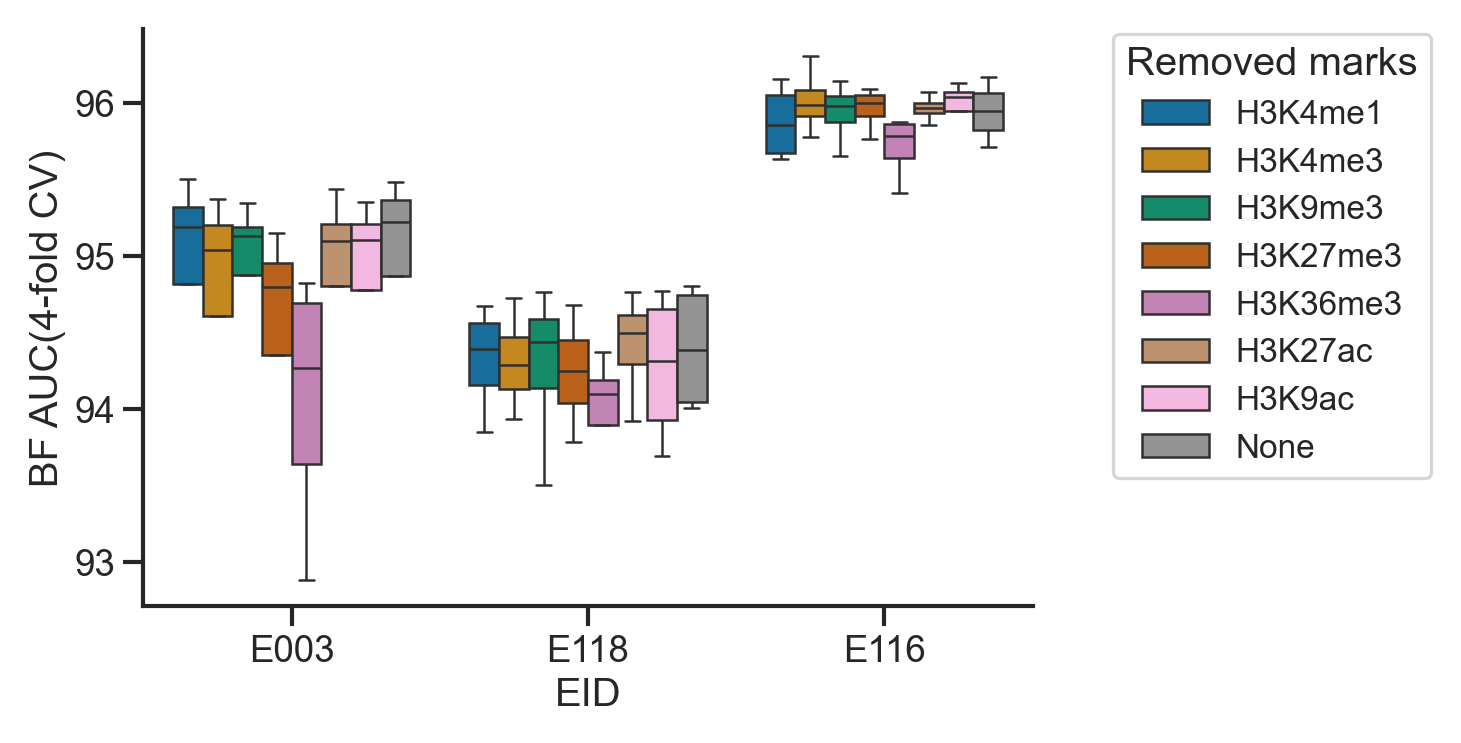

In [17]:
# df = ablations[ablations['remove_mark']=='all_marks'][['bf_auc','eid']]
fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.boxplot(data=ablations,y='bf_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6)
ax.legend().remove()  # Moves the legend outside the plot


handles, labels = ax.get_legend_handles_labels()
labels = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), title='Removed marks', fontsize=8)

ax.set_ylabel('BF AUC(4-fold CV)')
plt.xlabel('EID')
plt.legend().remove()
plt.show()

### bs ablation

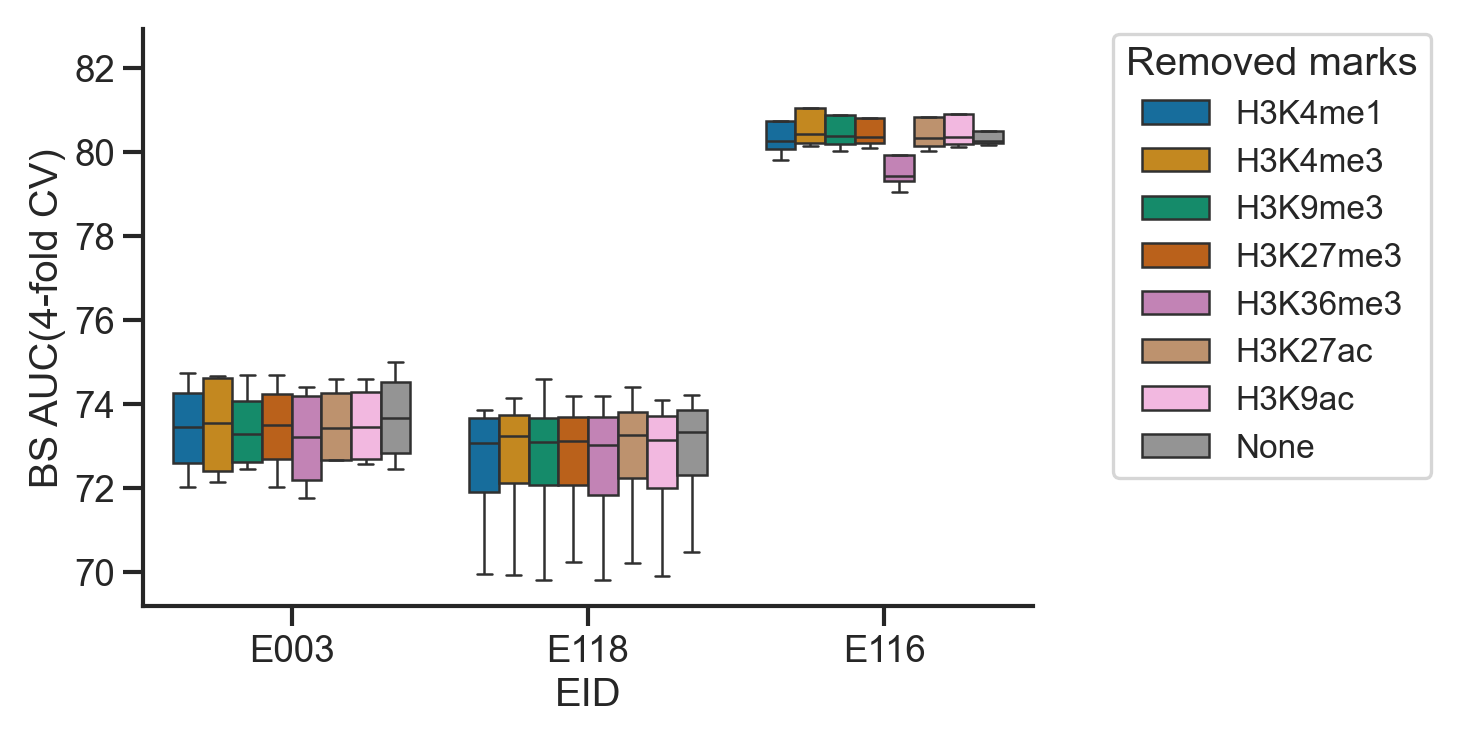

In [18]:
# df = ablations[ablations['remove_mark']=='all_marks'][['bf_auc','eid']]
fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.boxplot(data=ablations,y='bs_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6)
ax.legend().remove()  # Moves the legend outside the plot


handles, labels = ax.get_legend_handles_labels()
labels = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), title='Removed marks', fontsize=8)

ax.set_ylabel('BS AUC(4-fold CV)')
plt.xlabel('EID')
plt.legend().remove()

plt.show()

### mean ablations

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


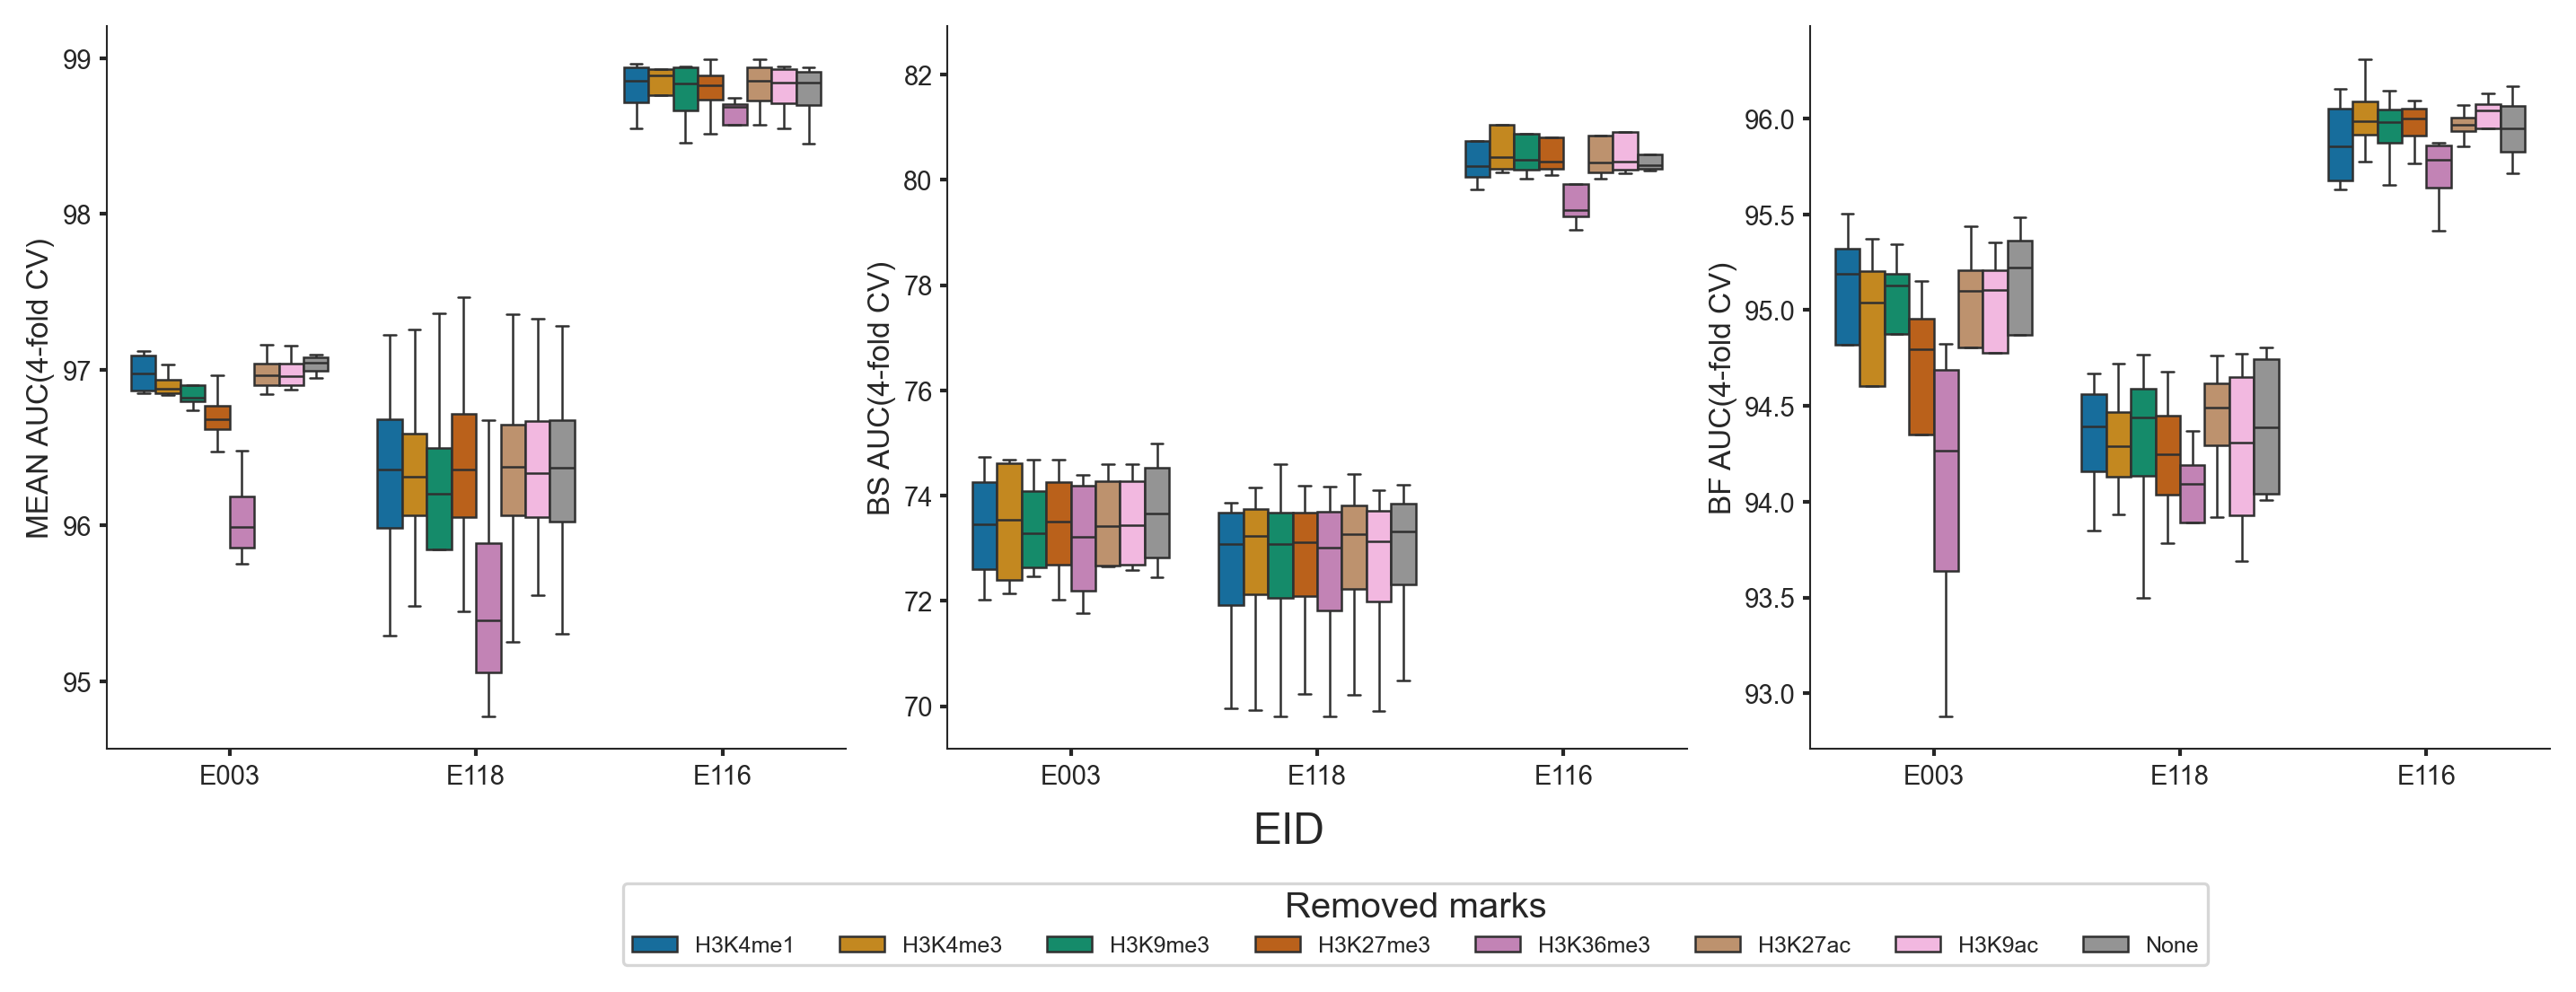

In [130]:
fig, ax = plt.subplots(1,3,constrained_layout=True,figsize=(24/2.54, 8/2.54))

sns.boxplot(data=ablation_mean,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[0])
ax[0].legend().remove()  # Moves the legend outside the plot
ax[0].set_ylabel('MEAN AUC(4-fold CV)')
ax[0].set_xlabel('')

sns.boxplot(data=ablations,y='bs_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[1])
ax[1].legend().remove()  # Moves the legend outside the plot
ax[1].set_ylabel('BS AUC(4-fold CV)')
ax[1].set_xlabel('')
sns.boxplot(data=ablations,y='bf_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[2])
ax[2].legend().remove()  # Moves the legend outside the plot
ax[2].set_ylabel('BF AUC(4-fold CV)')
ax[2].set_xlabel('')

handles, labels = ax[0].get_legend_handles_labels()
labels = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title='Removed marks', fontsize=6,ncol=8)


fig.supxlabel('EID')
plt.legend().remove()
plt.savefig('extra/datasets/figures/Figure3.a.eps', format='eps', bbox_inches='tight')

plt.show()

### Distance Importance

In [111]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
with open('extra/datasets/results/distance.csv','w') as w:
    line = ['bs_auc','bf_auc','fold','distance','eid']
    w.write('\t'.join(line) + '\n')
    for _eid in eids:
        for distance in [1000, 2000, 5000,10000,20000,40000]:
            for fold in [0,1,2,3]:

                checkpoints = f'checkpoints/{_eid}.{fold}.{distance}.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                bs_auc = ckpt['bs_label_val_auc']
                bf_auc = ckpt['bf_label_val_auc']
                line = [str(bs_auc),str(bf_auc),str(fold),str(distance), _eid]
                w.write('\t'.join(line) + '\n')
        

In [112]:
data = pd.read_csv('extra/datasets/results/distance.csv',sep='\t')
data


,bs_auc,bf_auc,fold,distance,eid
0,73.773461,92.653374,0,1000,E003
1,72.381944,93.429622,1,1000,E003
2,74.337496,93.999105,2,1000,E003
3,71.292128,93.909669,3,1000,E003
4,73.742764,93.222918,0,2000,E003
...,...,...,...,...,...
67,79.988160,96.066712,3,20000,E116
68,80.372848,95.605542,0,40000,E116
69,80.326466,96.171050,1,40000,E116
70,82.425110,96.110689,2,40000,E116


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


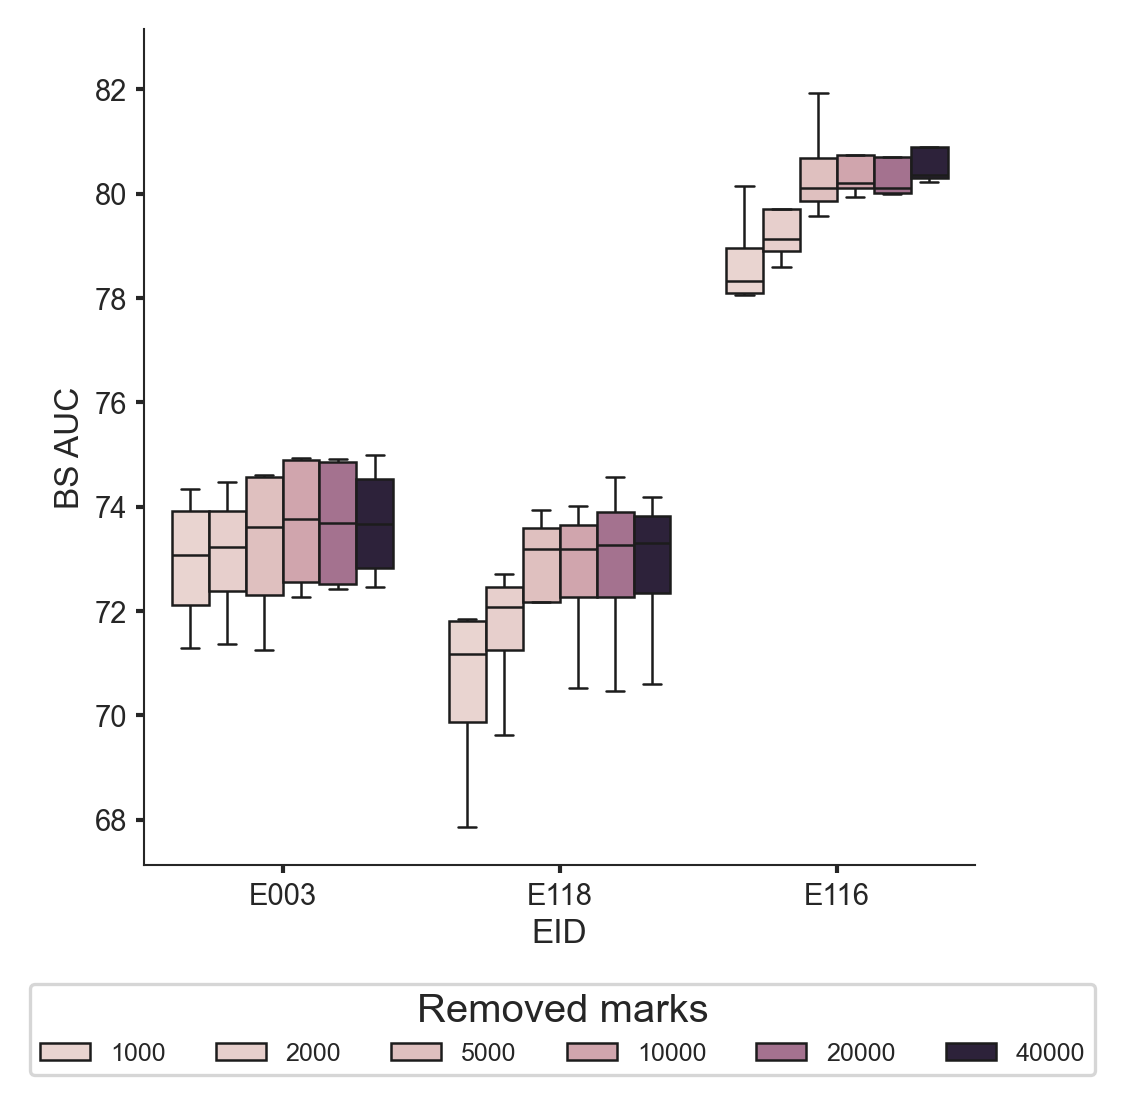

In [131]:
fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.boxplot(data=data,x='eid',y='bs_auc',hue='distance',fliersize=0,linewidth=0.6)
handles, labels = ax.get_legend_handles_labels()
labels = ["1000","2000","5000","10000","20000","40000"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title='Removed marks', fontsize=6,ncol=8)
ax.legend().remove()
ax.set_xlabel('EID')
ax.set_ylabel('BS AUC')

plt.savefig('extra/datasets/figures/Figure2.d_1.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


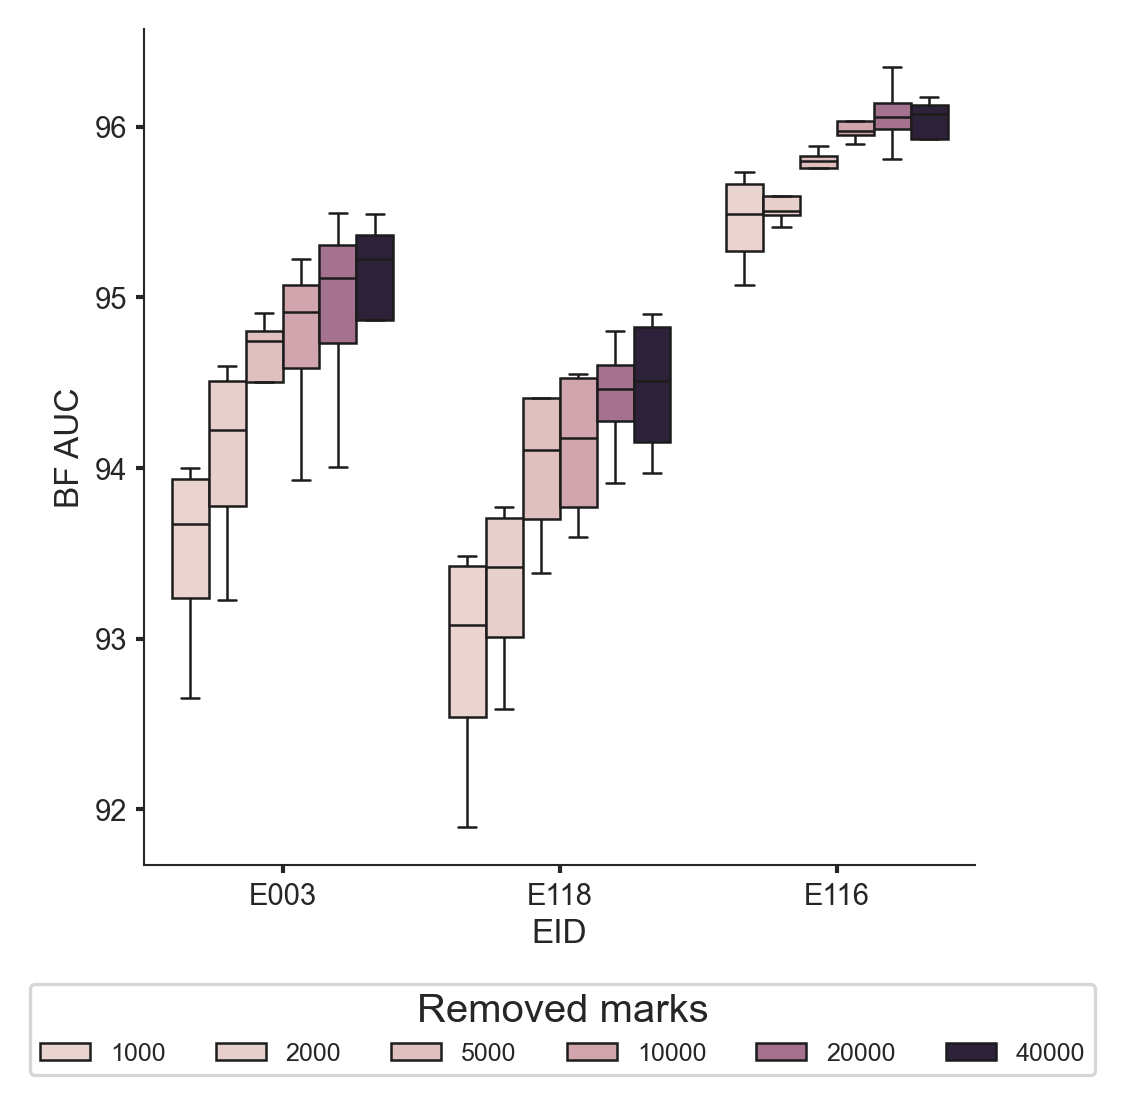

In [129]:
fig, ax = plt.subplots(1,1,constrained_layout=True)

ax = sns.boxplot(data=data,x='eid',y='bf_auc',hue='distance',fliersize=0,linewidth=0.6)
handles, labels = ax.get_legend_handles_labels()
labels = ["1000","2000","5000","10000","20000","40000"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title='Removed marks', fontsize=6,ncol=8)
ax.legend().remove()
ax.set_xlabel('EID')
ax.set_ylabel('BF AUC')
plt.savefig('extra/datasets/figures/Figure2.d_2.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


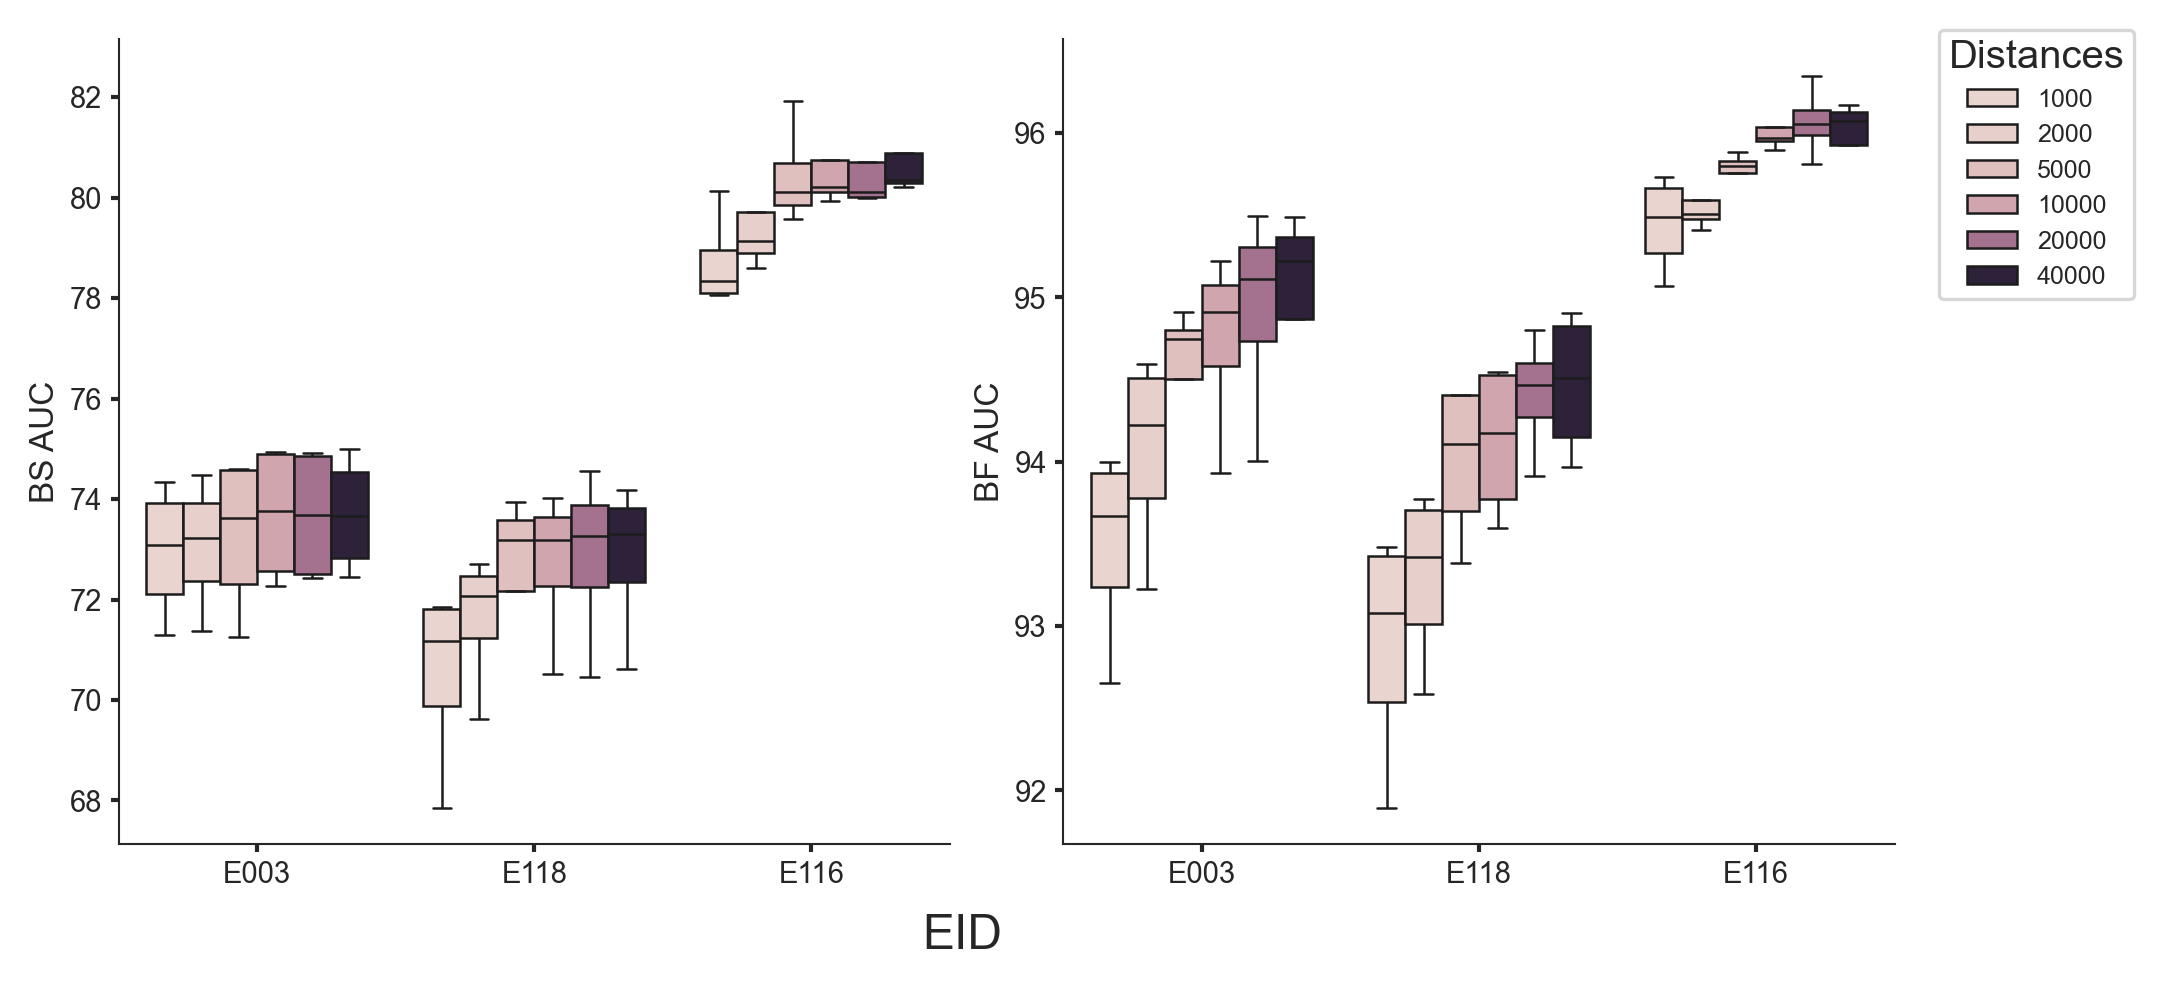

In [128]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(16/2.54, 8/2.54))
sns.set_palette("colorblind")

sns.boxplot(data=data,x='eid',y='bs_auc',hue='distance',fliersize=0,ax=ax[0],linewidth=0.6)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[0].set_ylabel('BS AUC')

sns.boxplot(data=data,x='eid',y='bf_auc',hue='distance',fliersize=0,ax=ax[1],linewidth=0.6)
handles, labels = ax[0].get_legend_handles_labels()
labels = ["1000","2000","5000","10000","20000","40000"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1.01) , title='Distances', fontsize=6,ncol=1)
ax[1].legend().remove()
ax[1].set_xlabel('')
ax[1].set_ylabel('BF AUC')

fig.supxlabel('EID')
plt.savefig('extra/datasets/figures/Figure2.d.eps', format='eps', bbox_inches='tight')
plt.show()